# Term Project V3 - ทำนายราคาอสังหาริมทรัพย์ แยกตาม property_type (แบบแยกทีละกลุ่ม ไม่ใช้ loop)

ไฟล์นี้ปรับปรุงจาก V2 โดยยังคงโครงเดิม คือ **เขียนแยกทีละกลุ่ม** ไม่มี `for` วนทั้งตาราง

- ทุกขั้นตอน (เตรียมข้อมูล → train → tune → ทำนาย) ของแต่ละกลุ่มอยู่ในหมวดของตัวเอง
- ตัวแปรของแต่ละกลุ่มแยกกันชัดเจน เช่น `X_train_condo`, `model_house`, `new_condo`
- ปิดท้ายด้วยหมวด "รวมผล" ที่เอาผลของทั้ง 5 กลุ่มมาวางเทียบกัน

กลุ่มที่ต้องแยก: **Condo, Detached House, Townhouse, Apartment, Land**

ข้อมูล: `ddproperty_2022-04-19.csv`

## 0) สิ่งที่เปลี่ยนจาก V2

| # | ปัญหาใน V2 | วิธีแก้ใน V3 | ผลที่คาดหวัง |
|---|---|---|---|
| 1 | เลือก `max_depth` จาก R² บน **test set** แล้วรายงานผลบน test set เดิม ทำให้ตัวเลขดีเกินจริง | ใช้ `GridSearchCV` (5-fold CV) บน **train set เท่านั้น** แล้วใช้ test set ครั้งเดียวตอนท้าย | ตัวเลขบน test เป็นค่าที่เชื่อถือได้ |
| 2 | `dropna` คอลัมน์ coverage ต่ำ (`floor_level`, `furnished`, `tenure`) ทำให้ Condo เหลือ ~30% และบ้านเดี่ยวเหลือ ~15% | `dropna` เฉพาะคอลัมน์ที่จำเป็นจริง ส่วนคอลัมน์ข้อความที่ว่างเติมเป็น `'Unknown'` และคอลัมน์ตัวเลขที่ว่างเติมเป็น `-1` | ได้ข้อมูลกลับมาหลายเท่า และเป็นตัวแทนตลาดมากขึ้น |
| 3 | ราคาเบ้มาก บ้าน/ที่ดินแพงไม่กี่แปลงครอบงำ RMSE และ R² | เทรนบน `log(1 + price)` แล้วแปลงกลับเป็นบาท สำหรับ Land ทำนาย **ราคาต่อหน่วยพื้นที่** แล้วคูณ `land_space` กลับ | โมเดลไม่ถูกดึงด้วยราคาสุดโต่ง โดยเฉพาะ Land |
| 4 | `floor_level` ถูก `LabelEncoder` เรียงแบบตัวอักษร (`'10' < '2'`) | แปลงเป็นตัวเลขด้วย `pd.to_numeric` | ลำดับชั้นถูกต้อง |
| 5 | `median_real_price` เป็น `-` ทุกแถว เพราะ map ชื่อเขตกับรหัสตัวเลข | เก็บข้อมูลดิบ `new_*` ไว้ แล้ว encode ลงตัวแปรใหม่ `X_new_*` | เห็นราคากลางจริงของเขตไว้เทียบ |
| 6 | `price kept` ที่พิมพ์คำนวณ quantile **หลัง** กรอง จึงไม่ใช่ cutoff จริง | `prepare()` คืนค่า `hi_price` ที่ใช้กรองจริงออกมา | ตัวเลข cutoff ถูกต้อง |
| 7 | ชื่อเขต/จังหวัดที่ไม่รู้จักถูกแทนด้วย mode แบบเงียบ ๆ | `encode_column()` พิมพ์เตือนทุกครั้งที่เกิด fallback และแก้ตัวอย่าง Land ที่ใส่ `Bang Plee` เป็น `Bangkok` | รู้ตัวเมื่อผลทำนายมาจากเขตอื่น |
| 8 | กราฟ "Class Distribution" ไม่มีความหมายกับ regression และ Townhouse ไม่มีกราฟ | เปลี่ยนเป็น histogram ของราคาและ log ราคา ครบทั้ง 5 กลุ่ม | เห็นความเบ้ของราคาชัดเจน |
| 9 | Feature importance แบบ impurity อย่างเดียว ซึ่งเอนเอียงไปทาง feature ที่มีค่าหลากหลาย (`city`) | เพิ่ม `permutation_importance` บน test set เทียบ | ตีความความสำคัญได้น่าเชื่อถือขึ้น |
| 10 | มีแถวซ้ำแต่ไม่ได้ลบ (ทำให้แถวเดียวกันอาจอยู่ทั้ง train และ test) | `drop_duplicates()` ก่อนแบ่งกลุ่ม | ไม่มีข้อมูลรั่วระหว่าง train/test |

> **หมายเหตุ:** ชุด feature ของแต่ละกลุ่ม **ยังเหมือน V2 ทุกตัว** เพื่อให้เห็นว่าผลที่เปลี่ยนมาจากระเบียบวิธี ไม่ใช่จากการเพิ่ม feature

## สิ่งที่เพิ่มในไฟล์นี้: Linear Regression เป็น baseline ก่อน Decision Tree

ไฟล์นี้คือ **V3 เดิมทุกอย่าง** (การ clean ข้อมูล, function, Decision Tree, ผลสรุป) แล้วเพิ่ม Linear Regression เข้าไปเพื่อแสดงก่อนว่า **ทำไมโมเดลเส้นตรงไม่เหมาะกับข้อมูลราคาอสังหา** จึงต้องใช้ Decision Tree

cell ที่เพิ่มเข้ามา:

| ตำแหน่ง | สิ่งที่เพิ่ม |
|---|---|
| ต่อจากหัวข้อ 1 | import ของ Linear Regression |
| ต่อจากหัวข้อ 6 | function ช่วยของ Linear Regression (function เดิมของ V3 ไม่ถูกแก้) |
| หัวข้อ X.1.1 ของทุกกลุ่ม | Linear Regression ของกลุ่มนั้น คั่นระหว่างการเตรียมข้อมูล (X.1) กับ Decision Tree (X.2) |
| หัวข้อ 12.9 | ตารางและกราฟเทียบ Linear Regression กับ Decision Tree ทั้ง 5 กลุ่ม |

**ข้อมูลที่ Linear ใช้คือข้อมูลที่ V3 clean แล้วทุกแถว** และใช้ train/test **ชุดเดียวกับ** Decision Tree (แบ่งด้วย index เดียวกัน) จึงเทียบกันได้ตรง ๆ

## 1) Import library

In [39]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

RANDOM_STATE = 42
TEST_SIZE = 0.3
PRICE_QUANTILE = 0.99
MIN_PRICE = 100_000

# ช่วงค่าที่ให้ GridSearchCV ลอง
PARAM_GRID = {
    'max_depth': [3, 5, 8, 10, 12, 15, None],
    'min_samples_leaf': [1, 5, 20],
}
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### 1.1 Import เพิ่มสำหรับ Linear Regression

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

## 2) Read File

ลบแถวที่ซ้ำกันทุกคอลัมน์ทิ้งตั้งแต่ตอนนี้ ไม่อย่างนั้นแถวเดียวกันอาจไปอยู่ทั้งใน train และ test ทำให้ผลดีเกินจริง

In [41]:
df = pd.read_csv('ddproperty_2022-04-19.csv', low_memory=False)
print('shape      :', df.shape)
print('duplicated :', df.duplicated().sum())

df = df.drop_duplicates()
print('shape after drop_duplicates:', df.shape)

shape      : (220557, 69)
duplicated : 0
shape after drop_duplicates: (220557, 69)


## 3) ลบคอลัมน์ที่เป็น null ทั้งหมด

คอลัมน์ที่ไม่มีข้อมูลเลยไม่มีประโยชน์กับโมเดล จึงตัดทิ้งก่อน

In [42]:
all_null_cols = [c for c in df.columns if df[c].isnull().all()]
print('all-null columns:', len(all_null_cols))

df = df.drop(columns=all_null_cols)
print('shape after drop:', df.shape)

all-null columns: 21
shape after drop: (220557, 48)


## 4) แยกเป็น 5 กลุ่ม (เขียนแยกทีละบรรทัด ไม่ใช้ `groupby` วน)

ถ้าใช้ `df.dropna()` ทั้งตารางจะเหลือข้อมูลไม่กี่ร้อยแถว เพราะ `land_space` null 61% และ `living_space` null 14.5%

วิธีแก้คือ **แยกกลุ่มก่อน แล้วจัดการ null ตามคอลัมน์ที่แต่ละกลุ่มต้องใช้**

In [43]:
df_condo = df[df['property_type'] == 'Condo'].copy()
df_house = df[df['property_type'] == 'Detached House'].copy()
df_townhouse = df[df['property_type'] == 'Townhouse'].copy()
df_apartment = df[df['property_type'] == 'Apartment'].copy()
df_land = df[df['property_type'] == 'Land'].copy()

print('df_condo    ', df_condo.shape)
print('df_house    ', df_house.shape)
print('df_townhouse', df_townhouse.shape)
print('df_apartment', df_apartment.shape)
print('df_land     ', df_land.shape)

df_condo     (129129, 48)
df_house     (42721, 48)
df_townhouse (18697, 48)
df_apartment (4553, 48)
df_land      (25457, 48)


### 4.1 จำนวนข้อมูลของแต่ละกลุ่ม (แยกสีทีละกลุ่ม)

นับจาก `len()` ของแต่ละ DataFrame ที่แยกไว้ข้างบน โดยไม่ใช้ `groupby` วน จึงเห็นว่ากลุ่มไหนหนักกว่ากันแค่ไหน

Condo มีข้อมูลมากกว่า 5 กลุ่มอื่นรวมกัน ทำให้แกน y ต้องใช้สเกล log ไม่งั้นแท่งของ Apartment จะแทบมองไม่เห็น

In [ ]:
labels = ['Condo', 'Detached House', 'Townhouse', 'Apartment', 'Land']
counts = [len(df_condo), len(df_house), len(df_townhouse), len(df_apartment), len(df_land)]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
total = sum(counts)

for label, count in zip(labels, counts):
    print(f'{label:<15}{count:>8,}  ({count / total * 100:5.2f}%)')
print(f'{"total":<15}{total:>8,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# แท่งซ้าย: จำนวนแถวจริง (log scale เพราะ Condo เยอะกว่าที่อื่นมาก)
axes[0].bar(labels, counts, color=colors)
axes[0].set_yscale('log')
axes[0].set_ylabel('listings (log scale)')
axes[0].set_title('listings per property_type')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_axisbelow(True)
for x, count in enumerate(counts):
    axes[0].text(x, count, f'{count:,}', ha='center', va='bottom', fontsize=8)

# แท่งขวา: สัดส่วนของทั้งชุด
axes[1].bar(labels, [c / total * 100 for c in counts], color=colors)
axes[1].set_ylabel('% of all listings')
axes[1].set_title('share of all listings')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_axisbelow(True)
for x, count in enumerate(counts):
    axes[1].text(x, count / total * 100, f'{count / total * 100:.1f}%',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 5) คอลัมน์ที่เลือกใช้ของแต่ละกลุ่ม

coverage (สัดส่วนแถวที่มีข้อมูล) ของคอลัมน์รองในแต่ละกลุ่ม:

| กลุ่ม | built_year | floor_level | tenure | furnished | land_space |
|---|---|---|---|---|---|
| Condo | 81.1% | 43.4% | 77.4% | 53.0% | 0% |
| Detached House | 4.3% | 40.5% | 26.5% | 42.4% | 93.1% |
| Townhouse | 5.8% | 74.2% | 33.8% | 33.1% | 91.4% |
| Apartment | 2.2% | 60.3% | 27.9% | 53.4% | 71.1% |
| Land | 0.3% | 4.6% | 29.6% | 0.1% | 100.0% |

แบ่งคอลัมน์เป็น 2 แบบ:

- **คอลัมน์จำเป็น** (`required`) ถ้าว่างจะลบแถวทิ้ง ได้แก่ `price`, `city`, `state` และพื้นที่หลักของกลุ่มนั้น (`living_space` หรือ `land_space` สำหรับ Land)
- **คอลัมน์เสริม** ถ้าว่างจะ **เติมค่า** แทนการลบแถว
  - ข้อความ (`tenure`, `furnished`) เติมเป็น `'Unknown'` ซึ่งกลายเป็นหมวดหนึ่งที่ต้นไม้ใช้แยกได้
  - ตัวเลข (`floor_level`, `built_year`, `bedroom_number`, ...) เติมเป็น `-1` ซึ่งต้นไม้แยกออกจากค่าจริงได้ด้วยการแบ่งครั้งเดียว

คอลัมน์ที่ coverage ต่ำมาก (< 6%) ยังตัดออกเหมือนเดิม เพราะเกือบทั้งหมดจะเป็นค่าที่เติม ไม่มีข้อมูลให้เรียนรู้

- `land_space` ของ Condo = **0%** (คอนโดไม่มีขนาดที่ดิน)
- `built_year` ของบ้าน/ทาวน์เฮาส์/อพาร์ตเมนต์ < 6%
- `Land` ใช้แค่ `land_space`, `city`, `state` เพราะ `living_space` = **0%** และคอลัมน์อื่น coverage ต่ำ

> สำหรับบ้านเดี่ยวและทาวน์เฮาส์ `floor_level` น่าจะหมายถึง **จำนวนชั้นของตัวบ้าน** ไม่ใช่ชั้นที่ห้องอยู่เหมือนคอนโด

## 6) ฟังก์ชันช่วยเตรียมข้อมูลและประเมินผล

ใช้ฟังก์ชันเดียวกันทั้ง 5 กลุ่ม แต่ **เรียกแยกทีละกลุ่ม** ในหมวดของแต่ละกลุ่ม

**เรื่อง target แบบ log:** ราคาอสังหาเบ้ขวามาก (ส่วนใหญ่หลักล้าน แต่มีบางแปลงหลายร้อยล้าน) ถ้าเทรนบนราคาตรง ๆ ต้นไม้จะพยายามแบ่งเพื่อลด error ของรายการแพงไม่กี่รายการ จึงเทรนบน `log(1 + price)` ซึ่งทำให้ error กลายเป็น **error แบบสัดส่วน** (พลาด 10% ของบ้าน 2 ล้าน กับ 10% ของบ้าน 20 ล้าน มีน้ำหนักเท่ากัน) แล้วแปลงกลับเป็นบาทด้วย `expm1` ตอนทำนาย

**ตัววัดผล** (คำนวณบน test set ทุกตัว):

| ตัววัด | ความหมาย |
|---|---|
| `MAE` | คลาดเฉลี่ยกี่บาท |
| `RMSE` | เหมือน MAE แต่ลงโทษความคลาดที่ใหญ่มากหนักกว่า |
| `R2` | R² บนราคาเป็นบาท (เทียบกับ V2 ได้ตรง ๆ) ถูกครอบงำด้วยรายการราคาแพง |
| `R2_log` | R² บน log ราคา บอกว่าโมเดลจับ **สัดส่วน** ราคาได้ดีแค่ไหนทั้งตลาด |
| `MdAPE` | ค่ามัธยฐานของ % ที่คลาด เช่น 15% แปลว่าครึ่งหนึ่งของรายการทำนายพลาดไม่เกิน 15% อ่านง่ายที่สุด |

In [44]:
def prepare(data, required, numeric, categorical, quantile=PRICE_QUANTILE):
    """ลบแถวที่คอลัมน์จำเป็นว่าง เติมค่าคอลัมน์เสริม แล้วกรองราคา outlier

    คืนค่า (ข้อมูลที่ใช้, X, price, hi_price) โดย hi_price คือ cutoff ที่ใช้กรองจริง
    """
    data = data.dropna(subset=['price'] + required).copy()

    # พื้นที่ต้องมากกว่า 0 (พื้นที่ 0 คือกรอกผิด และทำให้ราคาต่อพื้นที่หารไม่ได้)
    for col in required:
        if col in numeric:
            data = data[pd.to_numeric(data[col], errors='coerce') > 0]

    hi_price = data['price'].quantile(quantile)       # คำนวณก่อนกรอง
    data = data[(data['price'] >= MIN_PRICE) & (data['price'] <= hi_price)].copy()

    # ตัวเลข: แปลงเป็นตัวเลขจริง (เช่น floor_level '12' -> 12) ค่าที่แปลงไม่ได้/ว่าง = -1
    for col in numeric:
        data[col] = pd.to_numeric(data[col], errors='coerce').fillna(-1)
    # ข้อความ: ว่าง = 'Unknown'
    for col in categorical:
        data[col] = data[col].fillna('Unknown').astype(str)

    X = data[numeric + categorical].copy()
    return data, X, data['price'], hi_price


def to_target(price, X, per_area=None):
    """แปลงราคาเป็น target ที่ใช้เทรน: log(1 + price) หรือ log(1 + price / พื้นที่)"""
    if per_area is None:
        return np.log1p(price)
    return np.log1p(price / X[per_area])


def predict_price(model, X, per_area=None):
    """ทำนายแล้วแปลงกลับเป็นราคา (บาท)"""
    pred = np.expm1(model.predict(X))
    if per_area is not None:
        pred = pred * X[per_area].to_numpy()
    return pred


def metrics(model, X_test, price_test, per_area=None):
    """คำนวณ MAE / RMSE / R2 (บาท) / R2_log / MdAPE ของโมเดล"""
    pred = predict_price(model, X_test, per_area)
    return {
        'MAE': mean_absolute_error(price_test, pred),
        'RMSE': np.sqrt(mean_squared_error(price_test, pred)),
        'R2': r2_score(price_test, pred),
        'R2_log': r2_score(np.log1p(price_test), np.log1p(pred)),
        'MdAPE': np.median(np.abs(pred - price_test) / price_test) * 100,
    }


def report(model, X_test, price_test, model_name, per_area=None):
    """พิมพ์รายละเอียดของโมเดล แล้วคืนค่า metrics"""
    m = metrics(model, X_test, price_test, per_area)
    print(f'===== {model_name} =====')
    print(f'depth  = {model.get_depth()}')
    print(f'leaves = {model.get_n_leaves():,}')
    print(f"MAE    : {m['MAE']:,.0f}")
    print(f"RMSE   : {m['RMSE']:,.0f}")
    print(f"R²     : {m['R2']:.4f}")
    print(f"R² log : {m['R2_log']:.4f}")
    print(f"MdAPE  : {m['MdAPE']:.1f}%")
    print()
    return m


def tune(X_train, y_train, name):
    """หา max_depth / min_samples_leaf ด้วย 5-fold CV บน train set เท่านั้น"""
    grid = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                        PARAM_GRID, cv=CV, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)

    params = grid.cv_results_['params']
    table = pd.DataFrame({
        'max_depth': [str(p['max_depth']) for p in params],
        'min_samples_leaf': [p['min_samples_leaf'] for p in params],
        'cv_R2_log': grid.cv_results_['mean_test_score'],
    })
    table = table.pivot(index='max_depth', columns='min_samples_leaf', values='cv_R2_log')
    table = table.reindex([str(d) for d in PARAM_GRID['max_depth']])
    table.columns = [f'leaf={c}' for c in table.columns]

    print(f'===== {name}: CV R² (log price) บน train set =====')
    print(table.round(4).to_string())
    print('best params :', grid.best_params_)
    print(f'best CV R²  : {grid.best_score_:.4f}')
    return grid


def plot_price_distribution(price, name, hi_price):
    """histogram ของราคา (บาท) และ log10 ราคา"""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].hist(price / 1e6, bins=60)
    axes[0].set_xlabel('price (million THB)')
    axes[0].set_ylabel('listings')
    axes[0].set_title(f'{name}: price')
    axes[1].hist(np.log10(price), bins=60)
    axes[1].set_xlabel('log10(price)')
    axes[1].set_title(f'{name}: log10(price)')
    fig.suptitle(f'kept {MIN_PRICE:,} – {hi_price:,.0f} THB', fontsize=9)
    plt.tight_layout()
    plt.show()


def importance_table(model, X_test, y_test, features):
    """เทียบ importance แบบ impurity (จากต้นไม้) กับแบบ permutation (บน test set)"""
    perm = permutation_importance(model, X_test, y_test, n_repeats=5,
                                  random_state=RANDOM_STATE, scoring='r2', n_jobs=-1)
    return pd.DataFrame({
        'impurity': model.feature_importances_,
        'permutation': perm.importances_mean,
    }, index=features).sort_values('permutation', ascending=False)


def encode_column(values, encoder, fallback, col_name):
    """แปลงค่าข้อความเป็นตัวเลข ถ้าไม่เคยเจอในข้อมูลฝึกจะใช้ค่าที่พบบ่อยสุด และพิมพ์เตือน"""
    values = values.fillna('Unknown').astype(str)
    mapping = {name: code for code, name in enumerate(encoder.classes_)}
    codes = values.map(mapping)
    unknown = values[codes.isna()].unique()
    if len(unknown) > 0:
        print(f'⚠ {col_name}: ไม่พบ {list(unknown)} ในข้อมูลฝึก '
              f'→ ใช้ {encoder.classes_[fallback]!r} แทน (ผลทำนายแถวนี้อาจไม่ตรงพื้นที่จริง)')
    return codes.fillna(fallback).astype(int)

### 6.1 Function ช่วยของ Linear Regression

Linear Regression ต้องเตรียม feature ต่างจาก Decision Tree 3 เรื่อง (ทำใน `Pipeline` ของโมเดลเท่านั้น ข้อมูลที่ V3 clean แล้วไม่ถูกแก้):

1. **คอลัมน์ข้อความใช้ One-Hot แทน LabelEncoder** เพราะ Linear จะตีความรหัส `city = 3` ว่า "มากกว่า" `city = 1` เป็นเส้นตรง ซึ่งไม่มีความหมาย ส่วนต้นไม้แค่แบ่งกลุ่มจึงใช้รหัสตัวเลขได้
2. **ค่า `-1` ที่ V3 เติมแทนค่าว่าง** ต้นไม้แยกออกได้ด้วยการแบ่งครั้งเดียว แต่ Linear จะเห็นเป็นตัวเลขจริง (เช่น `built_year = -1` ห่างจาก 2018 สองพันปี) จึงแทน `-1` ด้วยค่ามัธยฐาน และเพิ่มคอลัมน์ 0/1 บอกว่าแถวนั้นเดิมเป็นค่าว่าง (`add_indicator=True`)
3. **StandardScaler** ปรับ feature ตัวเลขให้อยู่สเกลเดียวกัน

ทดลอง Linear 2 แบบ:

| แบบ | target | จุดประสงค์ |
|---|---|---|
| `Linear (price)` | ราคาเป็นบาทตรง ๆ | Linear Regression แบบพื้นฐานที่สุด |
| `Linear (log)` | target เดียวกับ Decision Tree ของ V3 (`log` ราคา และราคาต่อพื้นที่สำหรับ Land) และ feature ตัวเลขเป็น `log` ด้วย (log-log) | เทียบกับ Decision Tree แบบยุติธรรม เพราะใช้ target เดียวกัน |

ทำไม `Linear (log)` ต้อง log feature ด้วย: ถ้า target เป็น log แต่ feature เป็นตัวเลขดิบ ที่ดินแปลงใหญ่มาก ๆ (พื้นที่ห่างค่าเฉลี่ยหลายสิบเท่า) จะดันค่าทำนาย log ให้หลุดไปไกลมาก พอแปลงกลับเป็นบาทจะได้ราคาติดลบหรือค่าล้น ซึ่งเป็นตัวอย่างจุดอ่อนของเส้นตรงที่ **extrapolate ออกนอกช่วงข้อมูลได้ไม่จำกัด** ส่วนต้นไม้ไม่มีปัญหานี้ เพราะค่าทำนายของต้นไม้อยู่ในช่วงค่าที่เคยเห็นในข้อมูลฝึกเสมอ
ถ้ายังมีรายการที่แปลงกลับไม่ได้ จะถูกนับใน `neg_pred_%`

ตัววัดผลใช้ชุดเดียวกับ V3 และเพิ่ม `neg_pred_%` คือ % ของรายการที่โมเดลทำนาย **ราคาติดลบหรือเป็นศูนย์** ซึ่งเป็นไปไม่ได้ในความจริง

In [45]:
def make_linear(numeric, categorical, log_features=False):
    """Pipeline ของ Linear Regression: เติม -1 ด้วยมัธยฐาน + flag, (log), scale ตัวเลข, one-hot ข้อความ"""
    steps = [('impute', SimpleImputer(missing_values=-1, strategy='median', add_indicator=True))]
    if log_features:
        # log ของ feature ตัวเลข ใช้คู่กับ target แบบ log (log-log) กันไม่ให้แปลงใหญ่มากดันค่าทำนายจนหลุด
        steps.append(('log', FunctionTransformer(lambda x: np.log1p(np.clip(x, 0, None)))))
    steps.append(('scale', StandardScaler()))
    numeric_pipe = Pipeline(steps)
    preprocess = ColumnTransformer([
        ('num', numeric_pipe, numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ])
    return Pipeline([('preprocess', preprocess), ('model', LinearRegression())])


def linear_data(clean_data, X_train, X_test, features):
    """ดึงแถว train/test เดียวกับ Decision Tree จากข้อมูลที่ V3 clean แล้ว (ค่าข้อความยังไม่ถูก encode)"""
    return (clean_data.loc[X_train.index, features].copy(),
            clean_data.loc[X_test.index, features].copy())


def predict_price_linear(model, X, per_area=None):
    """ทำนายราคาจาก Linear (log) แล้วแปลงกลับเป็นบาท

    เส้นตรงอาจทำนาย log ราคาออกนอกช่วงจนแปลงกลับไม่ได้ (ล้นเป็น inf หรือได้ราคาติดลบ)
    รายการเหล่านั้นถูกตั้งเป็น 0 บาท และนับรวมใน neg_pred_%
    """
    with np.errstate(over='ignore', invalid='ignore'):
        pred = predict_price(model, X, per_area)
    return np.where(np.isfinite(pred) & (pred > 0), pred, 0.0)


def metrics_linear_log(model, X_test, price_test, per_area=None):
    """metrics ของ Linear ที่เทรนบน target แบบ log (เหมือน Decision Tree)"""
    return metrics_from_pred(predict_price_linear(model, X_test, per_area), price_test)


def metrics_linear_price(model, X_test, price_test):
    """metrics ของ Linear ที่เทรนบนราคาเป็นบาทตรง ๆ"""
    return metrics_from_pred(model.predict(X_test), price_test)


def metrics_from_pred(pred, price_test):
    """MAE / RMSE / R2 / R2_log / MdAPE + % ที่ทำนายราคา <= 0"""
    pred = np.asarray(pred, dtype=float)
    price_test = np.asarray(price_test, dtype=float)
    positive = pred > 0
    return {
        'MAE': mean_absolute_error(price_test, pred),
        'RMSE': np.sqrt(mean_squared_error(price_test, pred)),
        'R2': r2_score(price_test, pred),
        # log ของราคาติดลบหาไม่ได้ จึงคิด R2_log เฉพาะรายการที่ทำนายเป็นบวก
        'R2_log': r2_score(np.log1p(price_test[positive]), np.log1p(pred[positive])),
        'MdAPE': np.median(np.abs(pred - price_test) / price_test) * 100,
        'neg_pred_%': (~positive).mean() * 100,
    }


def report_linear(m, model_name):
    """พิมพ์ metrics ของ Linear Regression"""
    print(f'===== {model_name} =====')
    print(f"MAE    : {m['MAE']:,.0f}")
    print(f"RMSE   : {m['RMSE']:,.0f}")
    print(f"R²     : {m['R2']:.4f}")
    print(f"R² log : {m['R2_log']:.4f}")
    print(f"MdAPE  : {m['MdAPE']:.1f}%")
    print(f"ทำนายราคา <= 0 : {m['neg_pred_%']:.2f}% ของ test set")
    print()
    return m


def plot_linear(price_test, pred_price, pred_log, name):
    """Actual vs Predicted ของ Linear ทั้ง 2 แบบ (แกน log เพราะราคากระจายหลายหลัก)"""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    lo, hi = price_test.min(), price_test.max()
    for ax, pred, title in [(axes[0], pred_price, 'Linear (price)'),
                            (axes[1], pred_log, 'Linear (log)')]:
        shown = pred > 0
        ax.scatter(price_test[shown], pred[shown], s=4, alpha=0.25)
        ax.plot([lo, hi], [lo, hi], linestyle='--', color='black', linewidth=1)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('actual price (THB)')
        ax.set_title(f'{name}: {title}  (hidden: {(~shown).sum():,} preds <= 0)', fontsize=9)
    axes[0].set_ylabel('predicted price (THB)')
    plt.tight_layout()
    plt.show()

---

# 7) Condo

กลุ่มนี้มีข้อมูลเยอะที่สุด (~59%) และ **ไม่มี `land_space` เลย**

ราคาคอนโดผูกกับ `living_space` ปีที่สร้าง และทำเล

### 7.1 Condo — เตรียมข้อมูลและแบ่ง train/test

rows=126,431 จาก 129,129 (98%)  train=88,501  test=37,930
price kept: 100,000 - 80,000,000


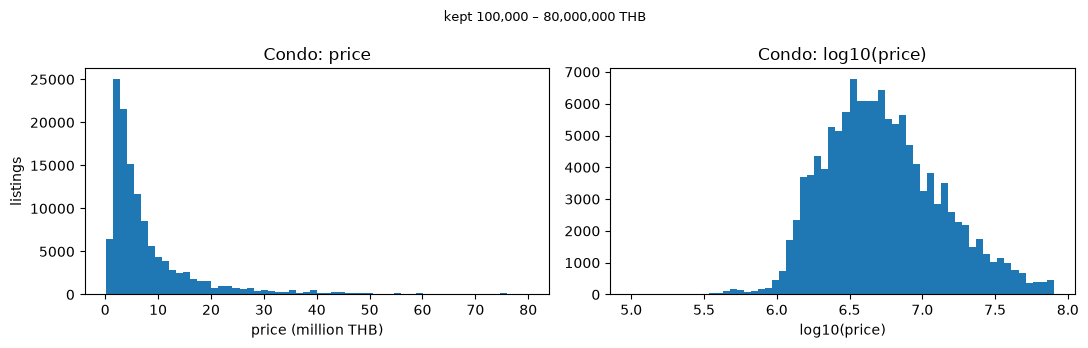

In [46]:
NUMERIC_CONDO = ['living_space', 'bedroom_number', 'bathroom_number', 'built_year', 'floor_level']
CATEGORICAL_CONDO = ['tenure', 'city', 'state']
FEATURES_CONDO = NUMERIC_CONDO + CATEGORICAL_CONDO
PER_AREA_CONDO = None

condo, X_condo, price_condo, hi_price_condo = prepare(
    df_condo, required=['living_space', 'city', 'state'],
    numeric=NUMERIC_CONDO, categorical=CATEGORICAL_CONDO)

# คอลัมน์ข้อความของ Condo: tenure, city, state
tenure_enc_condo = LabelEncoder().fit(X_condo['tenure'])
city_enc_condo = LabelEncoder().fit(X_condo['city'])
state_enc_condo = LabelEncoder().fit(X_condo['state'])

X_condo['tenure'] = tenure_enc_condo.transform(X_condo['tenure'])
X_condo['city'] = city_enc_condo.transform(X_condo['city'])
X_condo['state'] = state_enc_condo.transform(X_condo['state'])

X_train_condo, X_test_condo, price_train_condo, price_test_condo = train_test_split(
    X_condo, price_condo, test_size=TEST_SIZE, random_state=RANDOM_STATE)

y_train_condo = to_target(price_train_condo, X_train_condo, PER_AREA_CONDO)
y_test_condo = to_target(price_test_condo, X_test_condo, PER_AREA_CONDO)

print(f'rows={len(condo):,} จาก {len(df_condo):,} ({len(condo) / len(df_condo):.0%})  '
      f'train={len(X_train_condo):,}  test={len(X_test_condo):,}')
print(f'price kept: {MIN_PRICE:,} - {hi_price_condo:,.0f}')

plot_price_distribution(price_condo, 'Condo', hi_price_condo)

### 7.1.1 Condo — Linear Regression (baseline ก่อน Decision Tree)

ใช้ข้อมูล `condo` ที่ clean แล้วจาก 7.1 และแถว train/test เดียวกับ `X_train_condo` / `X_test_condo`

===== Linear (price) Condo =====
MAE    : 3,799,013
RMSE   : 7,048,777
R²     : 0.5584
R² log : 0.5671
MdAPE  : 36.9%
ทำนายราคา <= 0 : 0.78% ของ test set

===== Linear (log) Condo =====
MAE    : 6,936,637
RMSE   : 429,277,413
R²     : -1636.9756
R² log : 0.8067
MdAPE  : 22.1%
ทำนายราคา <= 0 : 0.00% ของ test set



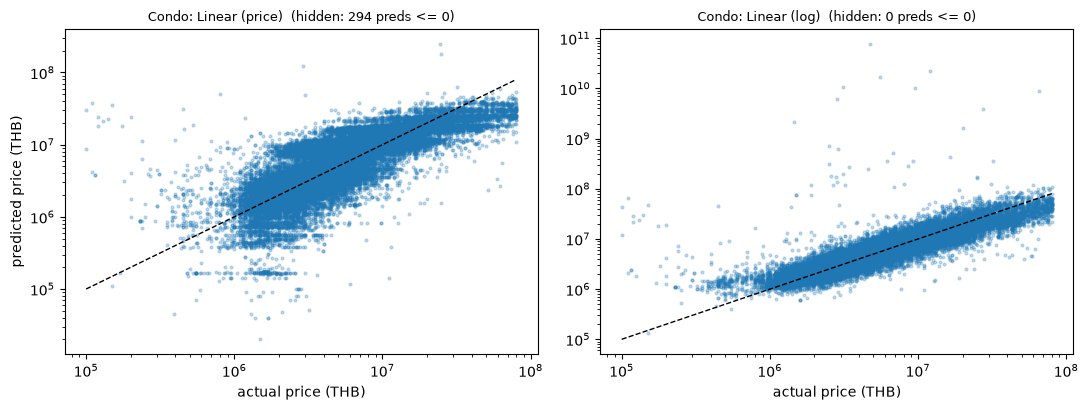

In [47]:
X_lin_train_condo, X_lin_test_condo = linear_data(condo, X_train_condo, X_test_condo, FEATURES_CONDO)

# แบบที่ 1: เทรนบนราคาเป็นบาทตรง ๆ
lin_price_condo = make_linear(NUMERIC_CONDO, CATEGORICAL_CONDO)
lin_price_condo.fit(X_lin_train_condo, price_train_condo)
res_condo_lin_price = report_linear(
    metrics_linear_price(lin_price_condo, X_lin_test_condo, price_test_condo), 'Linear (price) Condo')

# แบบที่ 2: เทรนบน target เดียวกับ Decision Tree (y_train_condo จาก 7.1)
# feature ตัวเลขก็ใช้ log ด้วย (log-log) ซึ่งเป็นรูปแบบมาตรฐานของ Linear กับราคาอสังหา
lin_log_condo = make_linear(NUMERIC_CONDO, CATEGORICAL_CONDO, log_features=True)
lin_log_condo.fit(X_lin_train_condo, y_train_condo)
res_condo_lin_log = report_linear(
    metrics_linear_log(lin_log_condo, X_lin_test_condo, price_test_condo, PER_AREA_CONDO),
    'Linear (log) Condo')

plot_linear(price_test_condo,
            lin_price_condo.predict(X_lin_test_condo),
            predict_price_linear(lin_log_condo, X_lin_test_condo, PER_AREA_CONDO),
            'Condo')

### 7.2 Condo — DecisionTreeRegressor ค่า default

ค่า default ไม่จำกัดความลึก ต้นไม้จะโตจนจำข้อมูลฝึก (overfit) ใช้เป็น baseline ไว้เทียบ

In [48]:
model_condo_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_condo_default.fit(X_train_condo, y_train_condo)

res_condo_default = report(
    model_condo_default, X_test_condo, price_test_condo, 'DT default Condo', PER_AREA_CONDO)

===== DT default Condo =====
depth  = 37
leaves = 45,727
MAE    : 1,531,713
RMSE   : 4,152,208
R²     : 0.8468
R² log : 0.8625
MdAPE  : 9.1%



### 7.3 Condo — Tune `max_depth` และ `min_samples_leaf` ด้วย 5-fold CV

`GridSearchCV` แบ่ง **train set** เป็น 5 ส่วน เทรน 4 ส่วนแล้ววัดผลส่วนที่เหลือ วนจนครบ แล้วเฉลี่ย R² จึงไม่แตะ test set เลย

- `max_depth` จำกัดความลึกของต้นไม้
- `min_samples_leaf` บังคับให้ใบแต่ละใบมีข้อมูลอย่างน้อยกี่แถว ช่วยให้ค่าทำนายของแต่ละใบนิ่งขึ้น โดยเฉพาะกลุ่มที่ข้อมูลน้อย

In [49]:
grid_condo = tune(X_train_condo, y_train_condo, 'Condo')

===== Condo: CV R² (log price) บน train set =====
           leaf=1  leaf=5  leaf=20
max_depth                         
3          0.6643  0.6643   0.6643
5          0.7467  0.7467   0.7467
8          0.8035  0.8049   0.8042
10         0.8311  0.8328   0.8311
12         0.8470  0.8501   0.8472
15         0.8588  0.8668   0.8583
None       0.8558  0.8740   0.8611
best params : {'max_depth': None, 'min_samples_leaf': 5}
best CV R²  : 0.8740


### 7.4 Condo — Final model

ใช้ค่าที่ CV เลือก (`grid_condo.best_params_`) แล้ววัดผลบน test set **ครั้งเดียว**

In [50]:
BEST_PARAMS_CONDO = grid_condo.best_params_
model_condo = grid_condo.best_estimator_   # GridSearchCV เทรนใหม่บน train set ทั้งหมดให้แล้ว

res_condo_tuned = report(
    model_condo, X_test_condo, price_test_condo, 'DT tuned Condo', PER_AREA_CONDO)

===== DT tuned Condo =====
depth  = 29
leaves = 10,890
MAE    : 1,637,586
RMSE   : 3,942,246
R²     : 0.8619
R² log : 0.8783
MdAPE  : 11.6%



### 7.5 Condo — Feature Importance

- `impurity` คือค่า `feature_importances_` ของต้นไม้ เอนเอียงไปทาง feature ที่มีค่าไม่ซ้ำเยอะ (เช่น `city`)
- `permutation` คือ R² (log) ที่ลดลงเมื่อสลับค่าของ feature นั้นใน test set แบบสุ่ม ยิ่งลดมากยิ่งสำคัญ น่าเชื่อถือกว่า

In [51]:
importance_condo = importance_table(model_condo, X_test_condo, y_test_condo, FEATURES_CONDO)
importance_condo.round(4)

,impurity,permutation
living_space,0.7286,1.1986
city,0.0768,0.2165
built_year,0.0957,0.2128
state,0.0411,0.1223
floor_level,0.0320,0.0438
bathroom_number,0.0123,0.0334
bedroom_number,0.0069,0.0310
tenure,0.0065,0.0259


### 7.6 Condo — ทดลองทำนายของใหม่

`new_condo` เก็บค่าดิบ (ชื่อเขตเป็นข้อความ) ส่วน `X_new_condo` คือค่าที่ encode แล้วสำหรับส่งเข้าโมเดล
`median_real_price` จึง map จากชื่อเขตได้ถูกต้อง

In [52]:
tenure_mode_condo = int(X_train_condo['tenure'].mode()[0])
city_mode_condo = int(X_train_condo['city'].mode()[0])
state_mode_condo = int(X_train_condo['state'].mode()[0])

new_condo = pd.DataFrame([
    {'living_space': 35, 'bedroom_number': 1, 'bathroom_number': 1,
     'built_year': 2018, 'floor_level': '12', 'tenure': 'Freehold',
     'city': 'Watthana', 'state': 'Bangkok'},
    {'living_space': 120, 'bedroom_number': 3, 'bathroom_number': 3,
     'built_year': 2021, 'floor_level': '25', 'tenure': 'Freehold',
     'city': 'Bang Rak', 'state': 'Bangkok'},
])

X_new_condo = new_condo[FEATURES_CONDO].copy()
X_new_condo[NUMERIC_CONDO] = X_new_condo[NUMERIC_CONDO].apply(pd.to_numeric, errors='coerce').fillna(-1)
X_new_condo['tenure'] = encode_column(new_condo['tenure'], tenure_enc_condo, tenure_mode_condo, 'tenure')
X_new_condo['city'] = encode_column(new_condo['city'], city_enc_condo, city_mode_condo, 'city')
X_new_condo['state'] = encode_column(new_condo['state'], state_enc_condo, state_mode_condo, 'state')

new_condo['property_type'] = 'Condo'
new_condo['predicted_price'] = predict_price(model_condo, X_new_condo, PER_AREA_CONDO)

median_condo = condo.groupby('city')['price'].median()
new_condo['median_real_price'] = new_condo['city'].map(median_condo)

new_condo[['property_type', 'living_space', 'state', 'city', 'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,living_space,state,city,predicted_price,median_real_price
0,Condo,35,Bangkok,Watthana,7737533.0,9600000.0
1,Condo,120,Bangkok,Bang Rak,29751613.0,9750000.0


---

# 8) Detached House

บ้านเดี่ยวมีทั้งพื้นที่ใช้สอยและขนาดที่ดิน แต่ `built_year` มีข้อมูลแค่ 4.3% จึงตัดออก

ใน V2 กลุ่มนี้เหลือข้อมูลแค่ ~15% เพราะ `dropna` ของ `floor_level` และ `furnished` ตอนนี้เติมค่าแทนแล้ว

### 8.1 Detached House — เตรียมข้อมูลและแบ่ง train/test

rows=38,629 จาก 42,721 (90%)  train=27,040  test=11,589
price kept: 100,000 - 170,000,000


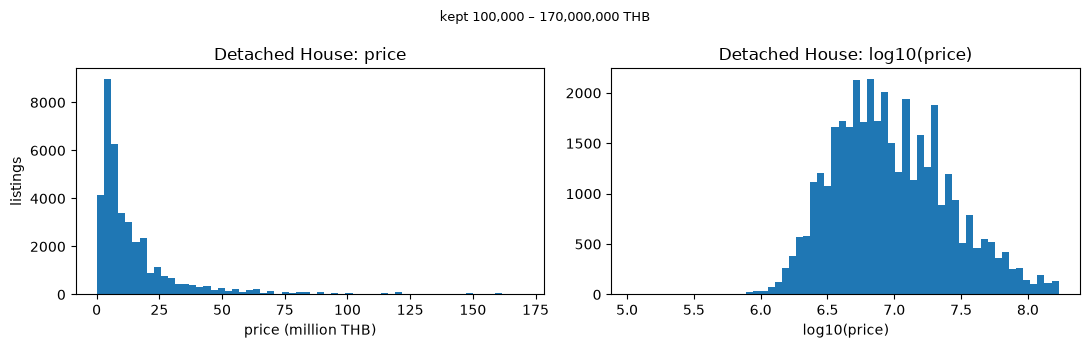

In [53]:
NUMERIC_HOUSE = ['living_space', 'land_space', 'bedroom_number', 'bathroom_number', 'floor_level']
CATEGORICAL_HOUSE = ['furnished', 'city', 'state']
FEATURES_HOUSE = NUMERIC_HOUSE + CATEGORICAL_HOUSE
PER_AREA_HOUSE = None

house, X_house, price_house, hi_price_house = prepare(
    df_house, required=['living_space', 'city', 'state'],
    numeric=NUMERIC_HOUSE, categorical=CATEGORICAL_HOUSE)

# คอลัมน์ข้อความของ Detached House: furnished, city, state
furnished_enc_house = LabelEncoder().fit(X_house['furnished'])
city_enc_house = LabelEncoder().fit(X_house['city'])
state_enc_house = LabelEncoder().fit(X_house['state'])

X_house['furnished'] = furnished_enc_house.transform(X_house['furnished'])
X_house['city'] = city_enc_house.transform(X_house['city'])
X_house['state'] = state_enc_house.transform(X_house['state'])

X_train_house, X_test_house, price_train_house, price_test_house = train_test_split(
    X_house, price_house, test_size=TEST_SIZE, random_state=RANDOM_STATE)

y_train_house = to_target(price_train_house, X_train_house, PER_AREA_HOUSE)
y_test_house = to_target(price_test_house, X_test_house, PER_AREA_HOUSE)

print(f'rows={len(house):,} จาก {len(df_house):,} ({len(house) / len(df_house):.0%})  '
      f'train={len(X_train_house):,}  test={len(X_test_house):,}')
print(f'price kept: {MIN_PRICE:,} - {hi_price_house:,.0f}')

plot_price_distribution(price_house, 'Detached House', hi_price_house)

### 8.1.1 Detached House — Linear Regression (baseline ก่อน Decision Tree)

ใช้ข้อมูล `house` ที่ clean แล้วจาก 8.1 และแถว train/test เดียวกับ `X_train_house` / `X_test_house`

===== Linear (price) Detached House =====
MAE    : 9,012,682
RMSE   : 17,471,881
R²     : 0.3764
R² log : 0.3255
MdAPE  : 51.3%
ทำนายราคา <= 0 : 5.53% ของ test set

===== Linear (log) Detached House =====
MAE    : 6,555,291
RMSE   : 15,637,439
R²     : 0.5005
R² log : 0.7623
MdAPE  : 26.5%
ทำนายราคา <= 0 : 0.00% ของ test set



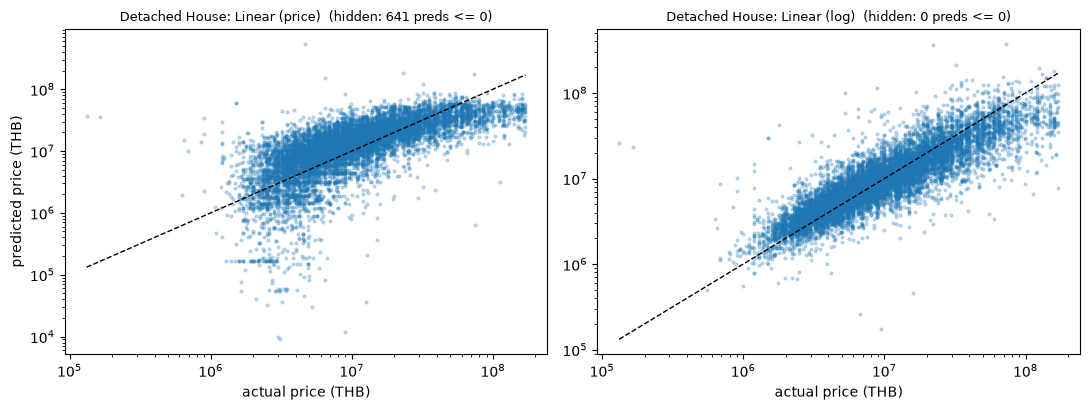

In [54]:
X_lin_train_house, X_lin_test_house = linear_data(house, X_train_house, X_test_house, FEATURES_HOUSE)

# แบบที่ 1: เทรนบนราคาเป็นบาทตรง ๆ
lin_price_house = make_linear(NUMERIC_HOUSE, CATEGORICAL_HOUSE)
lin_price_house.fit(X_lin_train_house, price_train_house)
res_house_lin_price = report_linear(
    metrics_linear_price(lin_price_house, X_lin_test_house, price_test_house), 'Linear (price) Detached House')

# แบบที่ 2: เทรนบน target เดียวกับ Decision Tree (y_train_house จาก 8.1)
# feature ตัวเลขก็ใช้ log ด้วย (log-log) ซึ่งเป็นรูปแบบมาตรฐานของ Linear กับราคาอสังหา
lin_log_house = make_linear(NUMERIC_HOUSE, CATEGORICAL_HOUSE, log_features=True)
lin_log_house.fit(X_lin_train_house, y_train_house)
res_house_lin_log = report_linear(
    metrics_linear_log(lin_log_house, X_lin_test_house, price_test_house, PER_AREA_HOUSE),
    'Linear (log) Detached House')

plot_linear(price_test_house,
            lin_price_house.predict(X_lin_test_house),
            predict_price_linear(lin_log_house, X_lin_test_house, PER_AREA_HOUSE),
            'Detached House')

### 8.2 Detached House — DecisionTreeRegressor ค่า default

ค่า default ไม่จำกัดความลึก ต้นไม้จะโตจนจำข้อมูลฝึก (overfit) ใช้เป็น baseline ไว้เทียบ

In [55]:
model_house_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_house_default.fit(X_train_house, y_train_house)

res_house_default = report(
    model_house_default, X_test_house, price_test_house, 'DT default Detached House', PER_AREA_HOUSE)

===== DT default Detached House =====
depth  = 38
leaves = 22,790
MAE    : 6,350,067
RMSE   : 15,901,424
R²     : 0.4835
R² log : 0.6700
MdAPE  : 18.9%



### 8.3 Detached House — Tune `max_depth` และ `min_samples_leaf` ด้วย 5-fold CV

`GridSearchCV` แบ่ง **train set** เป็น 5 ส่วน เทรน 4 ส่วนแล้ววัดผลส่วนที่เหลือ วนจนครบ แล้วเฉลี่ย R² จึงไม่แตะ test set เลย

- `max_depth` จำกัดความลึกของต้นไม้
- `min_samples_leaf` บังคับให้ใบแต่ละใบมีข้อมูลอย่างน้อยกี่แถว ช่วยให้ค่าทำนายของแต่ละใบนิ่งขึ้น โดยเฉพาะกลุ่มที่ข้อมูลน้อย

In [56]:
grid_house = tune(X_train_house, y_train_house, 'Detached House')

===== Detached House: CV R² (log price) บน train set =====
           leaf=1  leaf=5  leaf=20
max_depth                         
3          0.5816  0.5816   0.5816
5          0.6513  0.6508   0.6498
8          0.7085  0.7083   0.7080
10         0.7106  0.7224   0.7252
12         0.6975  0.7234   0.7316
15         0.6661  0.7192   0.7331
None       0.6310  0.7157   0.7334
best params : {'max_depth': None, 'min_samples_leaf': 20}
best CV R²  : 0.7334


### 8.4 Detached House — Final model

ใช้ค่าที่ CV เลือก (`grid_house.best_params_`) แล้ววัดผลบน test set **ครั้งเดียว**

In [57]:
BEST_PARAMS_HOUSE = grid_house.best_params_
model_house = grid_house.best_estimator_   # GridSearchCV เทรนใหม่บน train set ทั้งหมดให้แล้ว

res_house_tuned = report(
    model_house, X_test_house, price_test_house, 'DT tuned Detached House', PER_AREA_HOUSE)

===== DT tuned Detached House =====
depth  = 20
leaves = 1,011
MAE    : 6,266,507
RMSE   : 14,027,293
R²     : 0.5980
R² log : 0.7558
MdAPE  : 24.9%



### 8.5 Detached House — Feature Importance

- `impurity` คือค่า `feature_importances_` ของต้นไม้ เอนเอียงไปทาง feature ที่มีค่าไม่ซ้ำเยอะ (เช่น `city`)
- `permutation` คือ R² (log) ที่ลดลงเมื่อสลับค่าของ feature นั้นใน test set แบบสุ่ม ยิ่งลดมากยิ่งสำคัญ น่าเชื่อถือกว่า

In [58]:
importance_house = importance_table(model_house, X_test_house, y_test_house, FEATURES_HOUSE)
importance_house.round(4)

,impurity,permutation
living_space,0.5953,0.2657
bathroom_number,0.1884,0.2653
state,0.0729,0.1824
land_space,0.0690,0.1346
city,0.0549,0.0862
floor_level,0.0065,0.0152
furnished,0.0070,0.0107
bedroom_number,0.0059,0.0087


### 8.6 Detached House — ทดลองทำนายของใหม่

`new_house` เก็บค่าดิบ (ชื่อเขตเป็นข้อความ) ส่วน `X_new_house` คือค่าที่ encode แล้วสำหรับส่งเข้าโมเดล
`median_real_price` จึง map จากชื่อเขตได้ถูกต้อง

In [59]:
furnished_mode_house = int(X_train_house['furnished'].mode()[0])
city_mode_house = int(X_train_house['city'].mode()[0])
state_mode_house = int(X_train_house['state'].mode()[0])

new_house = pd.DataFrame([
    {'living_space': 250, 'land_space': 400, 'bedroom_number': 4,
     'bathroom_number': 4, 'floor_level': '2',
     'furnished': 'Fully Furnished', 'city': 'Hua Hin',
     'state': 'Prachuap Khiri Khan'},
    {'living_space': 120, 'land_space': 200, 'bedroom_number': 3,
     'bathroom_number': 2, 'floor_level': '1',
     'furnished': 'Unfurnished', 'city': 'Bang Plee',
     'state': 'Samut Prakan'},
])

X_new_house = new_house[FEATURES_HOUSE].copy()
X_new_house[NUMERIC_HOUSE] = X_new_house[NUMERIC_HOUSE].apply(pd.to_numeric, errors='coerce').fillna(-1)
X_new_house['furnished'] = encode_column(new_house['furnished'], furnished_enc_house, furnished_mode_house, 'furnished')
X_new_house['city'] = encode_column(new_house['city'], city_enc_house, city_mode_house, 'city')
X_new_house['state'] = encode_column(new_house['state'], state_enc_house, state_mode_house, 'state')

new_house['property_type'] = 'Detached House'
new_house['predicted_price'] = predict_price(model_house, X_new_house, PER_AREA_HOUSE)

median_house = house.groupby('city')['price'].median()
new_house['median_real_price'] = new_house['city'].map(median_house)

new_house[['property_type', 'living_space', 'land_space', 'state', 'city', 'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,living_space,land_space,state,city,predicted_price,median_real_price
0,Detached House,250,400,Prachuap Khiri Khan,Hua Hin,8587177.0,8000000.0
1,Detached House,120,200,Samut Prakan,Bang Plee,3480084.0,8497500.0


---

# 9) Townhouse

ชุด feature เหมือน Detached House แต่ข้อมูลน้อยกว่า (~8.5%) และราคากระจายแคบกว่า

`land_space` ยังไม่อยู่ใน `required` (เติม `-1` ถ้าว่าง) เพราะทาวน์เฮาส์บางประกาศไม่ระบุขนาดที่ดิน

### 9.1 Townhouse — เตรียมข้อมูลและแบ่ง train/test

rows=16,095 จาก 18,697 (86%)  train=11,266  test=4,829
price kept: 100,000 - 41,772,000


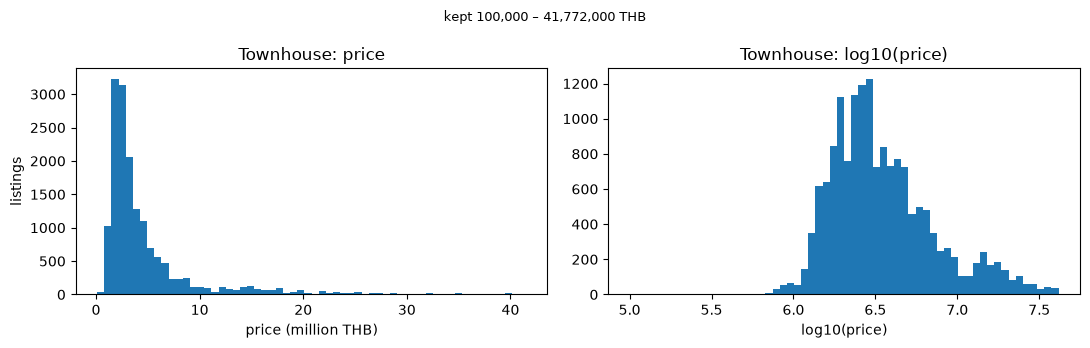

In [60]:
NUMERIC_TOWNHOUSE = ['living_space', 'land_space', 'bedroom_number', 'bathroom_number', 'floor_level']
CATEGORICAL_TOWNHOUSE = ['furnished', 'city', 'state']
FEATURES_TOWNHOUSE = NUMERIC_TOWNHOUSE + CATEGORICAL_TOWNHOUSE
PER_AREA_TOWNHOUSE = None

townhouse, X_townhouse, price_townhouse, hi_price_townhouse = prepare(
    df_townhouse, required=['living_space', 'city', 'state'],
    numeric=NUMERIC_TOWNHOUSE, categorical=CATEGORICAL_TOWNHOUSE)

# คอลัมน์ข้อความของ Townhouse: furnished, city, state
furnished_enc_townhouse = LabelEncoder().fit(X_townhouse['furnished'])
city_enc_townhouse = LabelEncoder().fit(X_townhouse['city'])
state_enc_townhouse = LabelEncoder().fit(X_townhouse['state'])

X_townhouse['furnished'] = furnished_enc_townhouse.transform(X_townhouse['furnished'])
X_townhouse['city'] = city_enc_townhouse.transform(X_townhouse['city'])
X_townhouse['state'] = state_enc_townhouse.transform(X_townhouse['state'])

X_train_townhouse, X_test_townhouse, price_train_townhouse, price_test_townhouse = train_test_split(
    X_townhouse, price_townhouse, test_size=TEST_SIZE, random_state=RANDOM_STATE)

y_train_townhouse = to_target(price_train_townhouse, X_train_townhouse, PER_AREA_TOWNHOUSE)
y_test_townhouse = to_target(price_test_townhouse, X_test_townhouse, PER_AREA_TOWNHOUSE)

print(f'rows={len(townhouse):,} จาก {len(df_townhouse):,} ({len(townhouse) / len(df_townhouse):.0%})  '
      f'train={len(X_train_townhouse):,}  test={len(X_test_townhouse):,}')
print(f'price kept: {MIN_PRICE:,} - {hi_price_townhouse:,.0f}')

plot_price_distribution(price_townhouse, 'Townhouse', hi_price_townhouse)

### 9.1.1 Townhouse — Linear Regression (baseline ก่อน Decision Tree)

ใช้ข้อมูล `townhouse` ที่ clean แล้วจาก 9.1 และแถว train/test เดียวกับ `X_train_townhouse` / `X_test_townhouse`

===== Linear (price) Townhouse =====
MAE    : 1,671,300
RMSE   : 3,206,390
R²     : 0.6449
R² log : 0.6171
MdAPE  : 27.0%
ทำนายราคา <= 0 : 1.80% ของ test set

===== Linear (log) Townhouse =====
MAE    : 1,383,889
RMSE   : 3,113,066
R²     : 0.6652
R² log : 0.7859
MdAPE  : 18.9%
ทำนายราคา <= 0 : 0.00% ของ test set



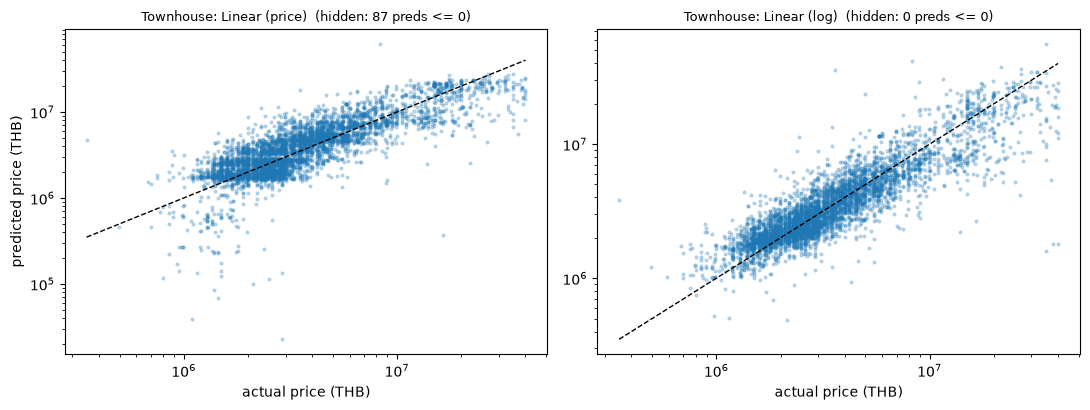

In [61]:
X_lin_train_townhouse, X_lin_test_townhouse = linear_data(townhouse, X_train_townhouse, X_test_townhouse, FEATURES_TOWNHOUSE)

# แบบที่ 1: เทรนบนราคาเป็นบาทตรง ๆ
lin_price_townhouse = make_linear(NUMERIC_TOWNHOUSE, CATEGORICAL_TOWNHOUSE)
lin_price_townhouse.fit(X_lin_train_townhouse, price_train_townhouse)
res_townhouse_lin_price = report_linear(
    metrics_linear_price(lin_price_townhouse, X_lin_test_townhouse, price_test_townhouse), 'Linear (price) Townhouse')

# แบบที่ 2: เทรนบน target เดียวกับ Decision Tree (y_train_townhouse จาก 9.1)
# feature ตัวเลขก็ใช้ log ด้วย (log-log) ซึ่งเป็นรูปแบบมาตรฐานของ Linear กับราคาอสังหา
lin_log_townhouse = make_linear(NUMERIC_TOWNHOUSE, CATEGORICAL_TOWNHOUSE, log_features=True)
lin_log_townhouse.fit(X_lin_train_townhouse, y_train_townhouse)
res_townhouse_lin_log = report_linear(
    metrics_linear_log(lin_log_townhouse, X_lin_test_townhouse, price_test_townhouse, PER_AREA_TOWNHOUSE),
    'Linear (log) Townhouse')

plot_linear(price_test_townhouse,
            lin_price_townhouse.predict(X_lin_test_townhouse),
            predict_price_linear(lin_log_townhouse, X_lin_test_townhouse, PER_AREA_TOWNHOUSE),
            'Townhouse')

### 9.2 Townhouse — DecisionTreeRegressor ค่า default

ค่า default ไม่จำกัดความลึก ต้นไม้จะโตจนจำข้อมูลฝึก (overfit) ใช้เป็น baseline ไว้เทียบ

In [62]:
model_townhouse_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_townhouse_default.fit(X_train_townhouse, y_train_townhouse)

res_townhouse_default = report(
    model_townhouse_default, X_test_townhouse, price_test_townhouse, 'DT default Townhouse', PER_AREA_TOWNHOUSE)

===== DT default Townhouse =====
depth  = 31
leaves = 9,764
MAE    : 1,396,959
RMSE   : 3,247,431
R²     : 0.6357
R² log : 0.7061
MdAPE  : 16.2%



### 9.3 Townhouse — Tune `max_depth` และ `min_samples_leaf` ด้วย 5-fold CV

`GridSearchCV` แบ่ง **train set** เป็น 5 ส่วน เทรน 4 ส่วนแล้ววัดผลส่วนที่เหลือ วนจนครบ แล้วเฉลี่ย R² จึงไม่แตะ test set เลย

- `max_depth` จำกัดความลึกของต้นไม้
- `min_samples_leaf` บังคับให้ใบแต่ละใบมีข้อมูลอย่างน้อยกี่แถว ช่วยให้ค่าทำนายของแต่ละใบนิ่งขึ้น โดยเฉพาะกลุ่มที่ข้อมูลน้อย

In [63]:
grid_townhouse = tune(X_train_townhouse, y_train_townhouse, 'Townhouse')

===== Townhouse: CV R² (log price) บน train set =====
           leaf=1  leaf=5  leaf=20
max_depth                         
3          0.6184  0.6184   0.6184
5          0.6930  0.6963   0.6962
8          0.7288  0.7323   0.7352
10         0.7241  0.7362   0.7429
12         0.7074  0.7358   0.7457
15         0.6792  0.7335   0.7457
None       0.6630  0.7319   0.7457
best params : {'max_depth': 12, 'min_samples_leaf': 20}
best CV R²  : 0.7457


### 9.4 Townhouse — Final model

ใช้ค่าที่ CV เลือก (`grid_townhouse.best_params_`) แล้ววัดผลบน test set **ครั้งเดียว**

In [64]:
BEST_PARAMS_TOWNHOUSE = grid_townhouse.best_params_
model_townhouse = grid_townhouse.best_estimator_   # GridSearchCV เทรนใหม่บน train set ทั้งหมดให้แล้ว

res_townhouse_tuned = report(
    model_townhouse, X_test_townhouse, price_test_townhouse, 'DT tuned Townhouse', PER_AREA_TOWNHOUSE)

===== DT tuned Townhouse =====
depth  = 12
leaves = 376
MAE    : 1,379,651
RMSE   : 2,948,881
R²     : 0.6996
R² log : 0.7760
MdAPE  : 18.1%



### 9.5 Townhouse — Feature Importance

- `impurity` คือค่า `feature_importances_` ของต้นไม้ เอนเอียงไปทาง feature ที่มีค่าไม่ซ้ำเยอะ (เช่น `city`)
- `permutation` คือ R² (log) ที่ลดลงเมื่อสลับค่าของ feature นั้นใน test set แบบสุ่ม ยิ่งลดมากยิ่งสำคัญ น่าเชื่อถือกว่า

In [65]:
importance_townhouse = importance_table(model_townhouse, X_test_townhouse, y_test_townhouse, FEATURES_TOWNHOUSE)
importance_townhouse.round(4)

,impurity,permutation
bathroom_number,0.5332,0.2428
living_space,0.2557,0.2203
state,0.0657,0.1436
city,0.0733,0.0999
land_space,0.0391,0.0657
floor_level,0.0135,0.0245
bedroom_number,0.0169,0.0213
furnished,0.0026,0.0025


### 9.6 Townhouse — ทดลองทำนายของใหม่

`new_townhouse` เก็บค่าดิบ (ชื่อเขตเป็นข้อความ) ส่วน `X_new_townhouse` คือค่าที่ encode แล้วสำหรับส่งเข้าโมเดล
`median_real_price` จึง map จากชื่อเขตได้ถูกต้อง

In [66]:
furnished_mode_townhouse = int(X_train_townhouse['furnished'].mode()[0])
city_mode_townhouse = int(X_train_townhouse['city'].mode()[0])
state_mode_townhouse = int(X_train_townhouse['state'].mode()[0])

new_townhouse = pd.DataFrame([
    {'living_space': 180, 'land_space': 200, 'bedroom_number': 3,
     'bathroom_number': 3, 'floor_level': '2',
     'furnished': 'Partially Furnished', 'city': 'Bang Plee',
     'state': 'Samut Prakan'},
])

X_new_townhouse = new_townhouse[FEATURES_TOWNHOUSE].copy()
X_new_townhouse[NUMERIC_TOWNHOUSE] = X_new_townhouse[NUMERIC_TOWNHOUSE].apply(pd.to_numeric, errors='coerce').fillna(-1)
X_new_townhouse['furnished'] = encode_column(new_townhouse['furnished'], furnished_enc_townhouse, furnished_mode_townhouse, 'furnished')
X_new_townhouse['city'] = encode_column(new_townhouse['city'], city_enc_townhouse, city_mode_townhouse, 'city')
X_new_townhouse['state'] = encode_column(new_townhouse['state'], state_enc_townhouse, state_mode_townhouse, 'state')

new_townhouse['property_type'] = 'Townhouse'
new_townhouse['predicted_price'] = predict_price(model_townhouse, X_new_townhouse, PER_AREA_TOWNHOUSE)

median_townhouse = townhouse.groupby('city')['price'].median()
new_townhouse['median_real_price'] = new_townhouse['city'].map(median_townhouse)

new_townhouse[['property_type', 'living_space', 'land_space', 'state', 'city', 'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,living_space,land_space,state,city,predicted_price,median_real_price
0,Townhouse,180,200,Samut Prakan,Bang Plee,3990234.0,2950000.0


---

# 10) Apartment

ข้อมูลน้อยที่สุด (~2%) และ `bedroom_number` / `bathroom_number` coverage < 5% จึงใช้แค่ 6 คอลัมน์

เพราะข้อมูลน้อย CV จึงสำคัญกับกลุ่มนี้ที่สุด ใน V2 การเลือก depth จาก test set ที่มีไม่กี่ร้อยแถวทำให้ตัวเลขผันผวนง่าย

### 10.1 Apartment — เตรียมข้อมูลและแบ่ง train/test

rows=4,117 จาก 4,553 (90%)  train=2,881  test=1,236
price kept: 100,000 - 336,000,000


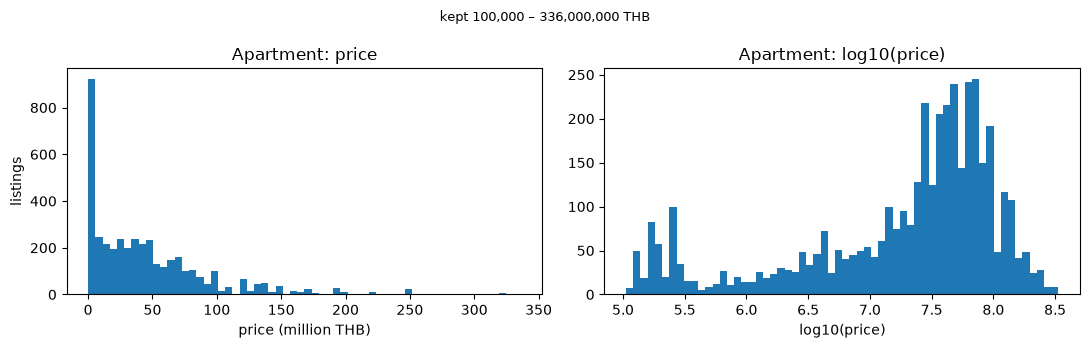

In [67]:
NUMERIC_APARTMENT = ['living_space', 'land_space', 'floor_level']
CATEGORICAL_APARTMENT = ['furnished', 'city', 'state']
FEATURES_APARTMENT = NUMERIC_APARTMENT + CATEGORICAL_APARTMENT
PER_AREA_APARTMENT = None

apartment, X_apartment, price_apartment, hi_price_apartment = prepare(
    df_apartment, required=['living_space', 'city', 'state'],
    numeric=NUMERIC_APARTMENT, categorical=CATEGORICAL_APARTMENT)

# คอลัมน์ข้อความของ Apartment: furnished, city, state
furnished_enc_apartment = LabelEncoder().fit(X_apartment['furnished'])
city_enc_apartment = LabelEncoder().fit(X_apartment['city'])
state_enc_apartment = LabelEncoder().fit(X_apartment['state'])

X_apartment['furnished'] = furnished_enc_apartment.transform(X_apartment['furnished'])
X_apartment['city'] = city_enc_apartment.transform(X_apartment['city'])
X_apartment['state'] = state_enc_apartment.transform(X_apartment['state'])

X_train_apartment, X_test_apartment, price_train_apartment, price_test_apartment = train_test_split(
    X_apartment, price_apartment, test_size=TEST_SIZE, random_state=RANDOM_STATE)

y_train_apartment = to_target(price_train_apartment, X_train_apartment, PER_AREA_APARTMENT)
y_test_apartment = to_target(price_test_apartment, X_test_apartment, PER_AREA_APARTMENT)

print(f'rows={len(apartment):,} จาก {len(df_apartment):,} ({len(apartment) / len(df_apartment):.0%})  '
      f'train={len(X_train_apartment):,}  test={len(X_test_apartment):,}')
print(f'price kept: {MIN_PRICE:,} - {hi_price_apartment:,.0f}')

plot_price_distribution(price_apartment, 'Apartment', hi_price_apartment)

### 10.1.1 Apartment — Linear Regression (baseline ก่อน Decision Tree)

ใช้ข้อมูล `apartment` ที่ clean แล้วจาก 10.1 และแถว train/test เดียวกับ `X_train_apartment` / `X_test_apartment`

===== Linear (price) Apartment =====
MAE    : 21,364,637
RMSE   : 34,611,712
R²     : 0.4912
R² log : 0.6171
MdAPE  : 48.6%
ทำนายราคา <= 0 : 2.18% ของ test set

===== Linear (log) Apartment =====
MAE    : 20,146,987
RMSE   : 37,875,101
R²     : 0.3908
R² log : 0.8574
MdAPE  : 36.7%
ทำนายราคา <= 0 : 0.00% ของ test set



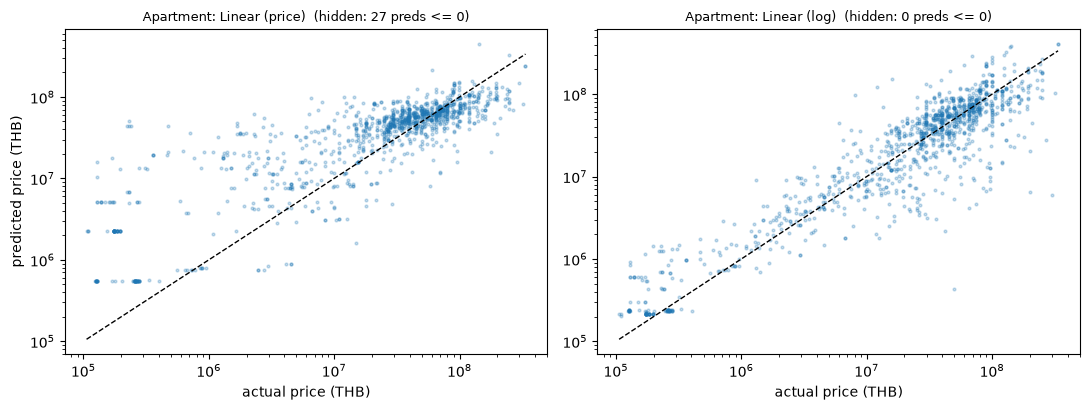

In [68]:
X_lin_train_apartment, X_lin_test_apartment = linear_data(apartment, X_train_apartment, X_test_apartment, FEATURES_APARTMENT)

# แบบที่ 1: เทรนบนราคาเป็นบาทตรง ๆ
lin_price_apartment = make_linear(NUMERIC_APARTMENT, CATEGORICAL_APARTMENT)
lin_price_apartment.fit(X_lin_train_apartment, price_train_apartment)
res_apartment_lin_price = report_linear(
    metrics_linear_price(lin_price_apartment, X_lin_test_apartment, price_test_apartment), 'Linear (price) Apartment')

# แบบที่ 2: เทรนบน target เดียวกับ Decision Tree (y_train_apartment จาก 10.1)
# feature ตัวเลขก็ใช้ log ด้วย (log-log) ซึ่งเป็นรูปแบบมาตรฐานของ Linear กับราคาอสังหา
lin_log_apartment = make_linear(NUMERIC_APARTMENT, CATEGORICAL_APARTMENT, log_features=True)
lin_log_apartment.fit(X_lin_train_apartment, y_train_apartment)
res_apartment_lin_log = report_linear(
    metrics_linear_log(lin_log_apartment, X_lin_test_apartment, price_test_apartment, PER_AREA_APARTMENT),
    'Linear (log) Apartment')

plot_linear(price_test_apartment,
            lin_price_apartment.predict(X_lin_test_apartment),
            predict_price_linear(lin_log_apartment, X_lin_test_apartment, PER_AREA_APARTMENT),
            'Apartment')

### 10.2 Apartment — DecisionTreeRegressor ค่า default

ค่า default ไม่จำกัดความลึก ต้นไม้จะโตจนจำข้อมูลฝึก (overfit) ใช้เป็น baseline ไว้เทียบ

In [69]:
model_apartment_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_apartment_default.fit(X_train_apartment, y_train_apartment)

res_apartment_default = report(
    model_apartment_default, X_test_apartment, price_test_apartment, 'DT default Apartment', PER_AREA_APARTMENT)

===== DT default Apartment =====
depth  = 27
leaves = 1,675
MAE    : 10,076,639
RMSE   : 28,982,557
R²     : 0.6433
R² log : 0.9157
MdAPE  : 5.2%



### 10.3 Apartment — Tune `max_depth` และ `min_samples_leaf` ด้วย 5-fold CV

`GridSearchCV` แบ่ง **train set** เป็น 5 ส่วน เทรน 4 ส่วนแล้ววัดผลส่วนที่เหลือ วนจนครบ แล้วเฉลี่ย R² จึงไม่แตะ test set เลย

- `max_depth` จำกัดความลึกของต้นไม้
- `min_samples_leaf` บังคับให้ใบแต่ละใบมีข้อมูลอย่างน้อยกี่แถว ช่วยให้ค่าทำนายของแต่ละใบนิ่งขึ้น โดยเฉพาะกลุ่มที่ข้อมูลน้อย

In [70]:
grid_apartment = tune(X_train_apartment, y_train_apartment, 'Apartment')

===== Apartment: CV R² (log price) บน train set =====
           leaf=1  leaf=5  leaf=20
max_depth                         
3          0.8339  0.8339   0.8346
5          0.8827  0.8842   0.8705
8          0.8871  0.8993   0.8813
10         0.8869  0.9020   0.8816
12         0.8862  0.9028   0.8817
15         0.8810  0.9036   0.8817
None       0.8853  0.9037   0.8817
best params : {'max_depth': None, 'min_samples_leaf': 5}
best CV R²  : 0.9037


### 10.4 Apartment — Final model

ใช้ค่าที่ CV เลือก (`grid_apartment.best_params_`) แล้ววัดผลบน test set **ครั้งเดียว**

In [71]:
BEST_PARAMS_APARTMENT = grid_apartment.best_params_
model_apartment = grid_apartment.best_estimator_   # GridSearchCV เทรนใหม่บน train set ทั้งหมดให้แล้ว

res_apartment_tuned = report(
    model_apartment, X_test_apartment, price_test_apartment, 'DT tuned Apartment', PER_AREA_APARTMENT)

===== DT tuned Apartment =====
depth  = 17
leaves = 400
MAE    : 11,349,461
RMSE   : 24,932,483
R²     : 0.7360
R² log : 0.9208
MdAPE  : 15.7%



### 10.5 Apartment — Feature Importance

- `impurity` คือค่า `feature_importances_` ของต้นไม้ เอนเอียงไปทาง feature ที่มีค่าไม่ซ้ำเยอะ (เช่น `city`)
- `permutation` คือ R² (log) ที่ลดลงเมื่อสลับค่าของ feature นั้นใน test set แบบสุ่ม ยิ่งลดมากยิ่งสำคัญ น่าเชื่อถือกว่า

In [72]:
importance_apartment = importance_table(model_apartment, X_test_apartment, y_test_apartment, FEATURES_APARTMENT)
importance_apartment.round(4)

,impurity,permutation
living_space,0.8271,1.1111
land_space,0.0687,0.7810
floor_level,0.0166,0.0732
city,0.0698,0.0426
state,0.0136,0.0315
furnished,0.0042,0.0254


### 10.6 Apartment — ทดลองทำนายของใหม่

`new_apartment` เก็บค่าดิบ (ชื่อเขตเป็นข้อความ) ส่วน `X_new_apartment` คือค่าที่ encode แล้วสำหรับส่งเข้าโมเดล
`median_real_price` จึง map จากชื่อเขตได้ถูกต้อง

In [73]:
furnished_mode_apartment = int(X_train_apartment['furnished'].mode()[0])
city_mode_apartment = int(X_train_apartment['city'].mode()[0])
state_mode_apartment = int(X_train_apartment['state'].mode()[0])

new_apartment = pd.DataFrame([
    {'living_space': 90, 'land_space': 120, 'floor_level': '8',
     'furnished': 'Fully Furnished', 'city': 'Chatuchak',
     'state': 'Bangkok'},
])

X_new_apartment = new_apartment[FEATURES_APARTMENT].copy()
X_new_apartment[NUMERIC_APARTMENT] = X_new_apartment[NUMERIC_APARTMENT].apply(pd.to_numeric, errors='coerce').fillna(-1)
X_new_apartment['furnished'] = encode_column(new_apartment['furnished'], furnished_enc_apartment, furnished_mode_apartment, 'furnished')
X_new_apartment['city'] = encode_column(new_apartment['city'], city_enc_apartment, city_mode_apartment, 'city')
X_new_apartment['state'] = encode_column(new_apartment['state'], state_enc_apartment, state_mode_apartment, 'state')

new_apartment['property_type'] = 'Apartment'
new_apartment['predicted_price'] = predict_price(model_apartment, X_new_apartment, PER_AREA_APARTMENT)

median_apartment = apartment.groupby('city')['price'].median()
new_apartment['median_real_price'] = new_apartment['city'].map(median_apartment)

new_apartment[['property_type', 'living_space', 'land_space', 'state', 'city', 'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,living_space,land_space,state,city,predicted_price,median_real_price
0,Apartment,90,120,Bangkok,Chatuchak,34045164.0,45000000.0


---

# 11) Land

ที่ดินเปล่ามีแค่ 3 คอลัมน์ที่ใช้ได้ (`land_space`, `city`, `state`) เพราะ `living_space` = **0%**

**เปลี่ยน target เป็นราคาต่อหน่วยพื้นที่:** ราคารวมของที่ดิน ≈ ราคาต่อหน่วย × ขนาด ต้นไม้ตัดสินใจเป็นขั้นบันได จึงเรียนรู้การ "คูณ" ได้ไม่ดี
ถ้าให้ต้นไม้ทำนาย `log(ราคา / land_space)` ซึ่งขึ้นกับทำเลเป็นหลัก แล้วคูณ `land_space` กลับตอนท้าย โมเดลจะทำงานง่ายขึ้นมาก
(ใน V2 Land ได้ R² แค่ 0.31)

### 11.1 Land — เตรียมข้อมูลและแบ่ง train/test

rows=24,886 จาก 25,457 (98%)  train=17,420  test=7,466
price kept: 100,000 - 1,363,792,500


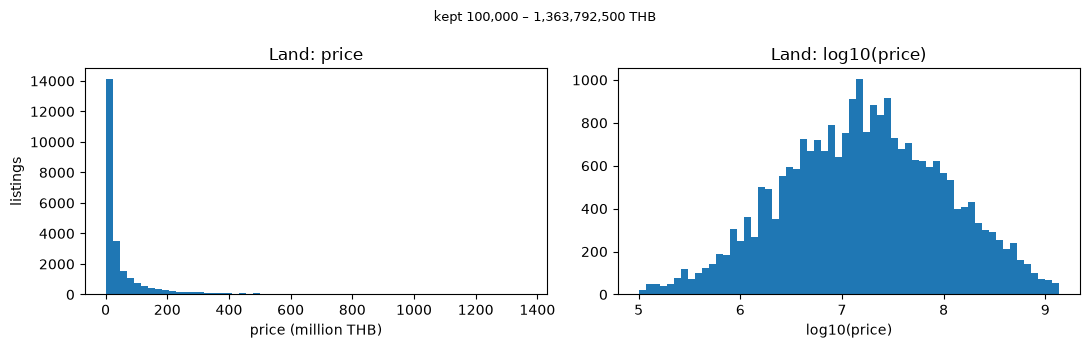

In [74]:
NUMERIC_LAND = ['land_space']
CATEGORICAL_LAND = ['city', 'state']
FEATURES_LAND = NUMERIC_LAND + CATEGORICAL_LAND
PER_AREA_LAND = 'land_space'

land, X_land, price_land, hi_price_land = prepare(
    df_land, required=['land_space', 'city', 'state'],
    numeric=NUMERIC_LAND, categorical=CATEGORICAL_LAND)

# คอลัมน์ข้อความของ Land: city, state
city_enc_land = LabelEncoder().fit(X_land['city'])
state_enc_land = LabelEncoder().fit(X_land['state'])

X_land['city'] = city_enc_land.transform(X_land['city'])
X_land['state'] = state_enc_land.transform(X_land['state'])

X_train_land, X_test_land, price_train_land, price_test_land = train_test_split(
    X_land, price_land, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Land: เทรนบน log ของราคาต่อหน่วยพื้นที่ แล้วคูณพื้นที่กลับตอนทำนาย
y_train_land = to_target(price_train_land, X_train_land, PER_AREA_LAND)
y_test_land = to_target(price_test_land, X_test_land, PER_AREA_LAND)

print(f'rows={len(land):,} จาก {len(df_land):,} ({len(land) / len(df_land):.0%})  '
      f'train={len(X_train_land):,}  test={len(X_test_land):,}')
print(f'price kept: {MIN_PRICE:,} - {hi_price_land:,.0f}')

plot_price_distribution(price_land, 'Land', hi_price_land)

### 11.1.1 Land — Linear Regression (baseline ก่อน Decision Tree)

ใช้ข้อมูล `land` ที่ clean แล้วจาก 11.1 และแถว train/test เดียวกับ `X_train_land` / `X_test_land`

แบบ `Linear (log)` ของ Land ทำนาย log ของราคาต่อหน่วยพื้นที่เหมือน Decision Tree แล้วคูณ `land_space` กลับ

===== Linear (price) Land =====
MAE    : 71,722,692
RMSE   : 135,969,442
R²     : 0.1204
R² log : -0.1262
MdAPE  : 201.4%
ทำนายราคา <= 0 : 0.67% ของ test set

===== Linear (log) Land =====
MAE    : 44,879,566
RMSE   : 129,119,390
R²     : 0.2068
R² log : 0.6448
MdAPE  : 54.3%
ทำนายราคา <= 0 : 0.00% ของ test set



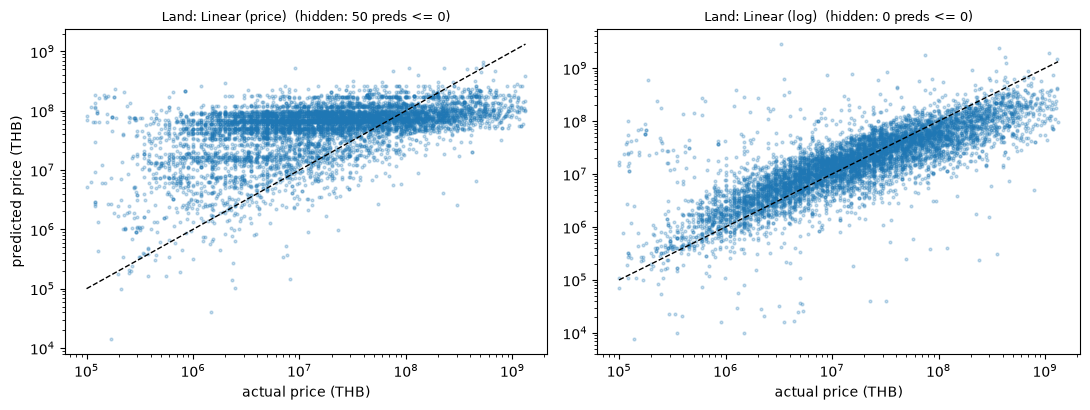

In [75]:
X_lin_train_land, X_lin_test_land = linear_data(land, X_train_land, X_test_land, FEATURES_LAND)

# แบบที่ 1: เทรนบนราคาเป็นบาทตรง ๆ
lin_price_land = make_linear(NUMERIC_LAND, CATEGORICAL_LAND)
lin_price_land.fit(X_lin_train_land, price_train_land)
res_land_lin_price = report_linear(
    metrics_linear_price(lin_price_land, X_lin_test_land, price_test_land), 'Linear (price) Land')

# แบบที่ 2: เทรนบน target เดียวกับ Decision Tree (y_train_land จาก 11.1)
# feature ตัวเลขก็ใช้ log ด้วย (log-log) ซึ่งเป็นรูปแบบมาตรฐานของ Linear กับราคาอสังหา
lin_log_land = make_linear(NUMERIC_LAND, CATEGORICAL_LAND, log_features=True)
lin_log_land.fit(X_lin_train_land, y_train_land)
res_land_lin_log = report_linear(
    metrics_linear_log(lin_log_land, X_lin_test_land, price_test_land, PER_AREA_LAND),
    'Linear (log) Land')

plot_linear(price_test_land,
            lin_price_land.predict(X_lin_test_land),
            predict_price_linear(lin_log_land, X_lin_test_land, PER_AREA_LAND),
            'Land')

### 11.2 Land — DecisionTreeRegressor ค่า default

ค่า default ไม่จำกัดความลึก ต้นไม้จะโตจนจำข้อมูลฝึก (overfit) ใช้เป็น baseline ไว้เทียบ

In [76]:
model_land_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
model_land_default.fit(X_train_land, y_train_land)

res_land_default = report(
    model_land_default, X_test_land, price_test_land, 'DT default Land', PER_AREA_LAND)

===== DT default Land =====
depth  = 41
leaves = 12,890
MAE    : 46,197,385
RMSE   : 132,407,030
R²     : 0.1659
R² log : 0.5295
MdAPE  : 44.5%



### 11.3 Land — Tune `max_depth` และ `min_samples_leaf` ด้วย 5-fold CV

`GridSearchCV` แบ่ง **train set** เป็น 5 ส่วน เทรน 4 ส่วนแล้ววัดผลส่วนที่เหลือ วนจนครบ แล้วเฉลี่ย R² จึงไม่แตะ test set เลย

- `max_depth` จำกัดความลึกของต้นไม้
- `min_samples_leaf` บังคับให้ใบแต่ละใบมีข้อมูลอย่างน้อยกี่แถว ช่วยให้ค่าทำนายของแต่ละใบนิ่งขึ้น โดยเฉพาะกลุ่มที่ข้อมูลน้อย

In [77]:
grid_land = tune(X_train_land, y_train_land, 'Land')

===== Land: CV R² (log price) บน train set =====
           leaf=1  leaf=5  leaf=20
max_depth                         
3          0.4366  0.4366   0.4366
5          0.4929  0.4884   0.4822
8          0.5674  0.5651   0.5629
10         0.6145  0.6195   0.6151
12         0.6289  0.6404   0.6357
15         0.6059  0.6412   0.6437
None       0.5301  0.6325   0.6437
best params : {'max_depth': None, 'min_samples_leaf': 20}
best CV R²  : 0.6437


### 11.4 Land — Final model

ใช้ค่าที่ CV เลือก (`grid_land.best_params_`) แล้ววัดผลบน test set **ครั้งเดียว**

In [78]:
BEST_PARAMS_LAND = grid_land.best_params_
model_land = grid_land.best_estimator_   # GridSearchCV เทรนใหม่บน train set ทั้งหมดให้แล้ว

res_land_tuned = report(
    model_land, X_test_land, price_test_land, 'DT tuned Land', PER_AREA_LAND)

===== DT tuned Land =====
depth  = 22
leaves = 646
MAE    : 44,255,318
RMSE   : 117,835,946
R²     : 0.3394
R² log : 0.6472
MdAPE  : 51.4%



### 11.5 Land — Feature Importance

- `impurity` คือค่า `feature_importances_` ของต้นไม้ เอนเอียงไปทาง feature ที่มีค่าไม่ซ้ำเยอะ (เช่น `city`)
- `permutation` คือ R² (log) ที่ลดลงเมื่อสลับค่าของ feature นั้นใน test set แบบสุ่ม ยิ่งลดมากยิ่งสำคัญ น่าเชื่อถือกว่า

In [79]:
importance_land = importance_table(model_land, X_test_land, y_test_land, FEATURES_LAND)
importance_land.round(4)

,impurity,permutation
state,0.5905,0.8970
city,0.1824,0.3433
land_space,0.2271,0.3118


### 11.6 Land — ทดลองทำนายของใหม่

`new_land` เก็บค่าดิบ (ชื่อเขตเป็นข้อความ) ส่วน `X_new_land` คือค่าที่ encode แล้วสำหรับส่งเข้าโมเดล
`median_real_price` จึง map จากชื่อเขตได้ถูกต้อง

In [80]:
city_mode_land = int(X_train_land['city'].mode()[0])
state_mode_land = int(X_train_land['state'].mode()[0])

new_land = pd.DataFrame([
    {'land_space': 500, 'city': 'Bang Plee', 'state': 'Samut Prakan'},   # V2 ใส่ state='Bangkok' ผิด
    {'land_space': 1000, 'city': 'Chatuchak', 'state': 'Bangkok'},
    {'land_space': 1500, 'city': 'Dusit', 'state': 'Bangkok'},
])

X_new_land = new_land[FEATURES_LAND].copy()
X_new_land[NUMERIC_LAND] = X_new_land[NUMERIC_LAND].apply(pd.to_numeric, errors='coerce').fillna(-1)
X_new_land['city'] = encode_column(new_land['city'], city_enc_land, city_mode_land, 'city')
X_new_land['state'] = encode_column(new_land['state'], state_enc_land, state_mode_land, 'state')

new_land['property_type'] = 'Land'
new_land['predicted_price'] = predict_price(model_land, X_new_land, PER_AREA_LAND)

median_land = land.groupby('city')['price'].median()
new_land['median_real_price'] = new_land['city'].map(median_land)

new_land[['property_type', 'land_space', 'state', 'city', 'predicted_price', 'median_real_price']].fillna('-').round(0)

,property_type,land_space,state,city,predicted_price,median_real_price
0,Land,500,Samut Prakan,Bang Plee,4603348.0,21918500.0
1,Land,1000,Bangkok,Chatuchak,39729119.0,23500000.0
2,Land,1500,Bangkok,Dusit,54578494.0,25450000.0


---

# 12) รวมผลของทั้ง 5 กลุ่ม

ทุกกลุ่มอยู่ในตัวแปรของตัวเองหมดแล้ว (`res_*`, `importance_*`, `new_*`) จึงเอามาวางเทียบกันได้โดยไม่ต้อง train ซ้ำ

### 12.1 จำนวนข้อมูลของแต่ละกลุ่ม

`kept_%` คือสัดส่วนแถวที่ใช้ได้เทียบกับข้อมูลทั้งกลุ่ม ซึ่ง V2 ได้แค่ ~30% (Condo) และ ~15% (บ้านเดี่ยว)

In [81]:
data_summary = pd.DataFrame([
    {'property_type': 'Condo', 'features': len(FEATURES_CONDO),
     'rows_all': len(df_condo), 'rows_used': len(condo),
     'train': len(X_train_condo), 'test': len(X_test_condo), 'price_max': hi_price_condo},
    {'property_type': 'Detached House', 'features': len(FEATURES_HOUSE),
     'rows_all': len(df_house), 'rows_used': len(house),
     'train': len(X_train_house), 'test': len(X_test_house), 'price_max': hi_price_house},
    {'property_type': 'Townhouse', 'features': len(FEATURES_TOWNHOUSE),
     'rows_all': len(df_townhouse), 'rows_used': len(townhouse),
     'train': len(X_train_townhouse), 'test': len(X_test_townhouse), 'price_max': hi_price_townhouse},
    {'property_type': 'Apartment', 'features': len(FEATURES_APARTMENT),
     'rows_all': len(df_apartment), 'rows_used': len(apartment),
     'train': len(X_train_apartment), 'test': len(X_test_apartment), 'price_max': hi_price_apartment},
    {'property_type': 'Land', 'features': len(FEATURES_LAND),
     'rows_all': len(df_land), 'rows_used': len(land),
     'train': len(X_train_land), 'test': len(X_test_land), 'price_max': hi_price_land},
]).set_index('property_type')

data_summary['kept_%'] = data_summary['rows_used'] / data_summary['rows_all'] * 100
data_summary.round(0)

,features,rows_all,rows_used,train,test,price_max,kept_%
property_type,,,,,,,
Condo,8,129129,126431,88501,37930,8.000000e+07,98.0
Detached House,8,42721,38629,27040,11589,1.700000e+08,90.0
Townhouse,8,18697,16095,11266,4829,4.177200e+07,86.0
Apartment,6,4553,4117,2881,1236,3.360000e+08,90.0
Land,3,25457,24886,17420,7466,1.363792e+09,98.0


### 12.2 เปรียบเทียบ default กับ tuned (บน test set)

In [82]:
comparison = pd.DataFrame([
    {'Method': 'DT default Condo', 'params': 'default', **res_condo_default},
    {'Method': 'DT tuned Condo', 'params': str(BEST_PARAMS_CONDO), **res_condo_tuned},
    {'Method': 'DT default Detached House', 'params': 'default', **res_house_default},
    {'Method': 'DT tuned Detached House', 'params': str(BEST_PARAMS_HOUSE), **res_house_tuned},
    {'Method': 'DT default Townhouse', 'params': 'default', **res_townhouse_default},
    {'Method': 'DT tuned Townhouse', 'params': str(BEST_PARAMS_TOWNHOUSE), **res_townhouse_tuned},
    {'Method': 'DT default Apartment', 'params': 'default', **res_apartment_default},
    {'Method': 'DT tuned Apartment', 'params': str(BEST_PARAMS_APARTMENT), **res_apartment_tuned},
    {'Method': 'DT default Land', 'params': 'default', **res_land_default},
    {'Method': 'DT tuned Land', 'params': str(BEST_PARAMS_LAND), **res_land_tuned},
]).set_index('Method')

comparison.round({'MAE': 0, 'RMSE': 0, 'R2': 4, 'R2_log': 4, 'MdAPE': 1})

,params,MAE,RMSE,R2,R2_log,MdAPE
Method,,,,,,
DT default Condo,default,1531713.0,4152208.0,0.8468,0.8625,9.1
DT tuned Condo,"{'max_depth': None, 'min_samples_leaf': 5}",1637586.0,3942246.0,0.8619,0.8783,11.6
DT default Detached House,default,6350067.0,15901424.0,0.4835,0.6700,18.9
DT tuned Detached House,"{'max_depth': None, 'min_samples_leaf': 20}",6266507.0,14027293.0,0.5980,0.7558,24.9
DT default Townhouse,default,1396959.0,3247431.0,0.6357,0.7061,16.2
DT tuned Townhouse,"{'max_depth': 12, 'min_samples_leaf': 20}",1379651.0,2948881.0,0.6996,0.7760,18.1
DT default Apartment,default,10076639.0,28982557.0,0.6433,0.9157,5.2
DT tuned Apartment,"{'max_depth': None, 'min_samples_leaf': 5}",11349461.0,24932483.0,0.7360,0.9208,15.7
DT default Land,default,46197385.0,132407030.0,0.1659,0.5295,44.5


### 12.3 เทียบค่าที่ CV เลือกกับผลจริงบน test set

ถ้า `cv_R2_log` กับ `test_R2_log` ใกล้กัน แปลว่าค่าที่ได้จาก CV เชื่อถือได้ และโมเดลไม่ได้ถูกปรับให้เข้ากับ test set โดยเฉพาะ

In [83]:
best_summary = pd.DataFrame([
    {'property_type': 'Condo', 'max_depth': str(BEST_PARAMS_CONDO['max_depth']),
     'min_samples_leaf': BEST_PARAMS_CONDO['min_samples_leaf'],
     'cv_R2_log': grid_condo.best_score_, 'test_R2_log': res_condo_tuned['R2_log']},
    {'property_type': 'Detached House', 'max_depth': str(BEST_PARAMS_HOUSE['max_depth']),
     'min_samples_leaf': BEST_PARAMS_HOUSE['min_samples_leaf'],
     'cv_R2_log': grid_house.best_score_, 'test_R2_log': res_house_tuned['R2_log']},
    {'property_type': 'Townhouse', 'max_depth': str(BEST_PARAMS_TOWNHOUSE['max_depth']),
     'min_samples_leaf': BEST_PARAMS_TOWNHOUSE['min_samples_leaf'],
     'cv_R2_log': grid_townhouse.best_score_, 'test_R2_log': res_townhouse_tuned['R2_log']},
    {'property_type': 'Apartment', 'max_depth': str(BEST_PARAMS_APARTMENT['max_depth']),
     'min_samples_leaf': BEST_PARAMS_APARTMENT['min_samples_leaf'],
     'cv_R2_log': grid_apartment.best_score_, 'test_R2_log': res_apartment_tuned['R2_log']},
    {'property_type': 'Land', 'max_depth': str(BEST_PARAMS_LAND['max_depth']),
     'min_samples_leaf': BEST_PARAMS_LAND['min_samples_leaf'],
     'cv_R2_log': grid_land.best_score_, 'test_R2_log': res_land_tuned['R2_log']},
]).set_index('property_type')

best_summary.round(4)

,max_depth,min_samples_leaf,cv_R2_log,test_R2_log
property_type,,,,
Condo,None,5,0.8740,0.8783
Detached House,None,20,0.7334,0.7558
Townhouse,12,20,0.7457,0.7760
Apartment,None,5,0.9037,0.9208
Land,None,20,0.6437,0.6472


### 12.4 Feature Importance ของทั้ง 5 กลุ่ม (permutation)

ใช้ค่า permutation เป็นหลัก เพราะวัดจากผลบน test set จริง ค่าใกล้ 0 หรือติดลบแปลว่า feature นั้นแทบไม่ช่วยทำนาย

In [84]:
importance_all = pd.DataFrame({
    'Condo': importance_condo['permutation'],
    'Detached House': importance_house['permutation'],
    'Townhouse': importance_townhouse['permutation'],
    'Apartment': importance_apartment['permutation'],
    'Land': importance_land['permutation'],
}).fillna(0)

importance_all.round(4)

,Condo,Detached House,Townhouse,Apartment,Land
bathroom_number,0.0334,0.2653,0.2428,0.0000,0.0000
bedroom_number,0.0310,0.0087,0.0213,0.0000,0.0000
built_year,0.2128,0.0000,0.0000,0.0000,0.0000
city,0.2165,0.0862,0.0999,0.0426,0.3433
floor_level,0.0438,0.0152,0.0245,0.0732,0.0000
furnished,0.0000,0.0107,0.0025,0.0254,0.0000
land_space,0.0000,0.1346,0.0657,0.7810,0.3118
living_space,1.1986,0.2657,0.2203,1.1111,0.0000
state,0.1223,0.1824,0.1436,0.0315,0.8970
tenure,0.0259,0.0000,0.0000,0.0000,0.0000


#### 12.4.1 กราฟ Feature Importance ของแต่ละกลุ่ม

ใช้ค่า permutation จากตารางข้างบนมาพล็อตต่อ โดยแยกสีตาม `property_type` เหมือนกราฟใน 4.1

- ซ้าย: ค่า permutation ดิบของแต่ละ feature เทียบกันตรง ๆ
- ขวา: ปรับให้สัดส่วนของแต่ละกลุ่มรวมกันเป็น 100% เพราะแต่ละกลุ่มมี feature ต่างกัน และจำนวนแถวต่างกัน ถ้าไม่ normalize จะเทียบกันไม่ได้

In [ ]:
group_names = ['Condo', 'Detached House', 'Townhouse', 'Apartment', 'Land']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
features = importance_all.index.tolist()
positions = np.arange(len(features))
width = 0.16

share_all = importance_all / importance_all.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ซ้าย: ค่า permutation ดิบ
for k, name in enumerate(group_names):
    axes[0].bar(positions + (k - 2) * width, importance_all[name], width, label=name, color=colors[k])

axes[0].set_xticks(positions)
axes[0].set_xticklabels(features, rotation=40, ha='right')
axes[0].set_ylabel('permutation importance (R² drop)')
axes[0].set_title('permutation importance by feature')

# ขวา: สัดส่วนของแต่ละกลุ่ม (รวมกัน 100%) เทียบข้ามกลุ่มได้
for k, name in enumerate(group_names):
    axes[1].bar(positions + (k - 2) * width, share_all[name], width, label=name, color=colors[k])

axes[1].set_xticks(positions)
axes[1].set_xticklabels(features, rotation=40, ha='right')
axes[1].set_ylabel('share of importance (%)')
axes[1].set_title('normalized share per group (sum = 100%)')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**วิธีอ่านตารางนี้**

- ใน V2 (importance แบบ impurity) `living_space` สำคัญที่สุดทุกกลุ่มที่มีพื้นที่ใช้สอย ให้ตรวจว่าแบบ permutation ยังให้ผลเหมือนเดิมหรือไม่
- ถ้า `city` ได้ค่า impurity สูงแต่ permutation ต่ำ แปลว่าต้นไม้ใช้ `city` แบ่งบ่อย แต่การแบ่งเหล่านั้นไม่ได้ช่วยกับข้อมูลใหม่จริง
- สำหรับ Land ค่า `land_space` จะลดลงเมื่อเทียบกับ V2 เป็นเรื่องปกติ เพราะตอนนี้ target คือราคาต่อพื้นที่ ซึ่งขึ้นกับทำเล (`city`, `state`) มากกว่าขนาด ขนาดถูกนำไปคูณกลับนอกโมเดลแล้ว

### 12.5 กราฟเทียบค่า R² ของแต่ละกลุ่ม

ซ้ายคือ R² บนราคาเป็นบาท (เทียบกับ V2 ได้) ขวาคือ R² บน log ราคา (สิ่งที่โมเดลถูกเทรนให้ทำ)

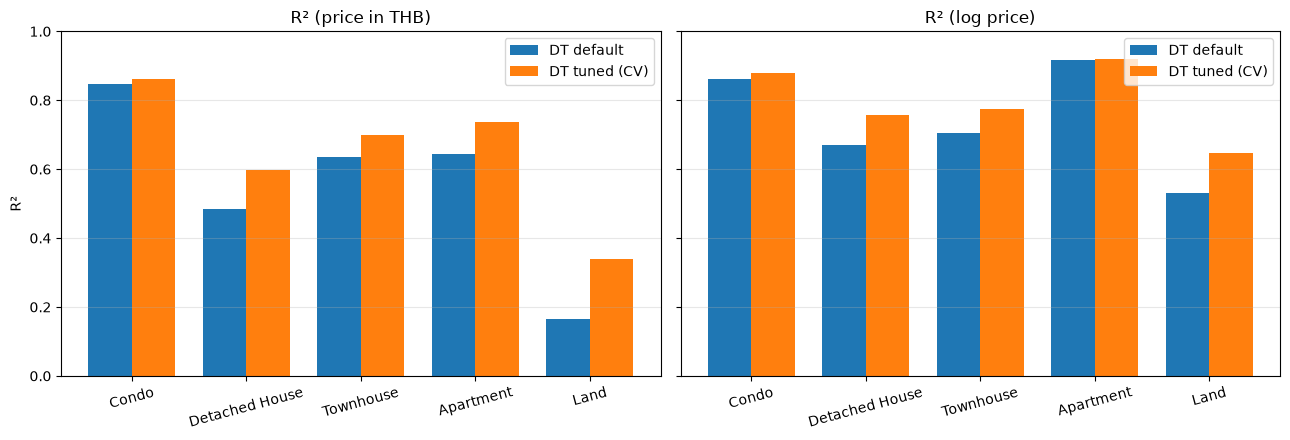

In [85]:
group_names = ['Condo', 'Detached House', 'Townhouse', 'Apartment', 'Land']
res_default_all = [res_condo_default, res_house_default, res_townhouse_default,
                   res_apartment_default, res_land_default]
res_tuned_all = [res_condo_tuned, res_house_tuned, res_townhouse_tuned,
                 res_apartment_tuned, res_land_tuned]

positions = np.arange(len(group_names))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

axes[0].bar(positions - width / 2, [r['R2'] for r in res_default_all], width, label='DT default')
axes[0].bar(positions + width / 2, [r['R2'] for r in res_tuned_all], width, label='DT tuned (CV)')
axes[0].set_title('R² (price in THB)')

axes[1].bar(positions - width / 2, [r['R2_log'] for r in res_default_all], width, label='DT default')
axes[1].bar(positions + width / 2, [r['R2_log'] for r in res_tuned_all], width, label='DT tuned (CV)')
axes[1].set_title('R² (log price)')

axes[0].set_ylabel('R²')
axes[0].set_ylim(min(0, min(r['R2'] for r in res_default_all + res_tuned_all)), 1)
for ax in axes:
    ax.set_xticks(positions)
    ax.set_xticklabels(group_names, rotation=15)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

### 12.6 ตารางราคาที่ทำนายของใหม่ (ทุกกลุ่มรวมกัน)

In [86]:
DISPLAY_COLS = ['property_type', 'living_space', 'land_space', 'state', 'city',
                'predicted_price', 'median_real_price']

result = pd.concat([
    new_condo.reindex(columns=DISPLAY_COLS),
    new_house.reindex(columns=DISPLAY_COLS),
    new_townhouse.reindex(columns=DISPLAY_COLS),
    new_apartment.reindex(columns=DISPLAY_COLS),
    new_land.reindex(columns=DISPLAY_COLS),
], ignore_index=True)

result.round(0).fillna('-')

,property_type,living_space,land_space,state,city,predicted_price,median_real_price
0,Condo,35.0,-,Bangkok,Watthana,7737533.0,9600000.0
1,Condo,120.0,-,Bangkok,Bang Rak,29751613.0,9750000.0
2,Detached House,250.0,400.0,Prachuap Khiri Khan,Hua Hin,8587177.0,8000000.0
3,Detached House,120.0,200.0,Samut Prakan,Bang Plee,3480084.0,8497500.0
4,Townhouse,180.0,200.0,Samut Prakan,Bang Plee,3990234.0,2950000.0
5,Apartment,90.0,120.0,Bangkok,Chatuchak,34045164.0,45000000.0
6,Land,-,500.0,Samut Prakan,Bang Plee,4603348.0,21918500.0
7,Land,-,1000.0,Bangkok,Chatuchak,39729119.0,23500000.0
8,Land,-,1500.0,Bangkok,Dusit,54578494.0,25450000.0


### 12.7 สรุปผลของ tuned model ทุกกลุ่ม

ตารางนี้สร้างจากผลที่รันจริง จึงตรงกับข้อมูลเสมอ (V2 พิมพ์ตัวเลขไว้ใน markdown ซึ่งต้องแก้ด้วยมือทุกครั้งที่รันใหม่)

In [87]:
final_table = pd.DataFrame([
    {'property_type': 'Condo', **res_condo_tuned},
    {'property_type': 'Detached House', **res_house_tuned},
    {'property_type': 'Townhouse', **res_townhouse_tuned},
    {'property_type': 'Apartment', **res_apartment_tuned},
    {'property_type': 'Land', **res_land_tuned},
]).set_index('property_type')

final_table.round({'MAE': 0, 'RMSE': 0, 'R2': 4, 'R2_log': 4, 'MdAPE': 1})

,MAE,RMSE,R2,R2_log,MdAPE
property_type,,,,,
Condo,1637586.0,3942246.0,0.8619,0.8783,11.6
Detached House,6266507.0,14027293.0,0.5980,0.7558,24.9
Townhouse,1379651.0,2948881.0,0.6996,0.7760,18.1
Apartment,11349461.0,24932483.0,0.7360,0.9208,15.7
Land,44255318.0,117835946.0,0.3394,0.6472,51.4


### 12.8 เทียบกับ V2

ผล tuned ของ V2 (อ้างอิง):

| กลุ่ม | max_depth | MAE | RMSE | R² |
|---|---|---|---|---|
| Condo | 15 | 948,467 | 2,134,123 | 0.8722 |
| Detached House | 8 | 5,007,522 | 10,761,332 | 0.5569 |
| Townhouse | 8 | 1,381,549 | 2,532,026 | 0.6945 |
| Apartment | 10 | 8,735,492 | 19,453,523 | 0.8009 |
| Land | 8 | 54,583,452 | 120,781,252 | 0.3059 |

**ข้อควรระวังในการเทียบ**

1. ตัวเลข V2 **ดีเกินจริง** อยู่แล้ว เพราะเลือก depth จาก test set ตัวเลข V3 จึงอาจไม่สูงกว่าในบางกลุ่ม แต่เป็นตัวเลขที่เชื่อถือได้
2. test set ของ V3 **ใหญ่และหลากหลายกว่า** (รวมประกาศที่กรอกไม่ครบ ซึ่ง V2 ทิ้งไป) จึงเป็นโจทย์ที่ยากกว่าและใกล้การใช้งานจริงกว่า
3. ให้ดู `MdAPE` และ `R2_log` ประกอบ ไม่ใช่ R² บาทอย่างเดียว เพราะ R² บาทยังถูกรายการราคาแพงไม่กี่รายการครอบงำ

**ขั้นต่อไปที่ทำได้ ถ้าต้องการให้ผลดีขึ้นอีก**

- ใช้ `RandomForestRegressor` หรือ `HistGradientBoostingRegressor` แทนต้นไม้ต้นเดียว มักได้ R² สูงขึ้นชัดเจน
- แทน `city` ด้วย target encoding (ราคามัธยฐานต่อพื้นที่ของเขต คำนวณจาก train set เท่านั้น)
- สำหรับกลุ่มที่มีบ้าน ลองทำนายราคาต่อ `living_space` แบบเดียวกับ Land

### 12.9 Linear Regression vs Decision Tree

เทียบบน test set ชุดเดียวกันทุกโมเดล:

- `Linear (price)` เทรนบนราคาเป็นบาท
- `Linear (log)` เทรนบน target เดียวกับ Decision Tree
- `DT tuned` คือ Decision Tree ที่ผ่าน CV ของ V3

In [88]:
lin_vs_dt = pd.DataFrame([
    {'property_type': 'Condo', 'model': 'Linear (price)', **res_condo_lin_price},
    {'property_type': 'Condo', 'model': 'Linear (log)', **res_condo_lin_log},
    {'property_type': 'Condo', 'model': 'DT tuned', **res_condo_tuned, 'neg_pred_%': 0.0},
    {'property_type': 'Detached House', 'model': 'Linear (price)', **res_house_lin_price},
    {'property_type': 'Detached House', 'model': 'Linear (log)', **res_house_lin_log},
    {'property_type': 'Detached House', 'model': 'DT tuned', **res_house_tuned, 'neg_pred_%': 0.0},
    {'property_type': 'Townhouse', 'model': 'Linear (price)', **res_townhouse_lin_price},
    {'property_type': 'Townhouse', 'model': 'Linear (log)', **res_townhouse_lin_log},
    {'property_type': 'Townhouse', 'model': 'DT tuned', **res_townhouse_tuned, 'neg_pred_%': 0.0},
    {'property_type': 'Apartment', 'model': 'Linear (price)', **res_apartment_lin_price},
    {'property_type': 'Apartment', 'model': 'Linear (log)', **res_apartment_lin_log},
    {'property_type': 'Apartment', 'model': 'DT tuned', **res_apartment_tuned, 'neg_pred_%': 0.0},
    {'property_type': 'Land', 'model': 'Linear (price)', **res_land_lin_price},
    {'property_type': 'Land', 'model': 'Linear (log)', **res_land_lin_log},
    {'property_type': 'Land', 'model': 'DT tuned', **res_land_tuned, 'neg_pred_%': 0.0},
]).set_index(['property_type', 'model'])

lin_vs_dt.round({'MAE': 0, 'RMSE': 0, 'R2': 4, 'R2_log': 4, 'MdAPE': 1, 'neg_pred_%': 2})

MAE         RMSE         R2  R2_log  \
property_type  model                                                        
Condo          Linear (price)   3799013.0    7048777.0     0.5584  0.5671   
               Linear (log)     6936637.0  429277413.0 -1636.9756  0.8067   
               DT tuned         1637586.0    3942246.0     0.8619  0.8783   
Detached House Linear (price)   9012682.0   17471881.0     0.3764  0.3255   
               Linear (log)     6555291.0   15637439.0     0.5005  0.7623   
               DT tuned         6266507.0   14027293.0     0.5980  0.7558   
Townhouse      Linear (price)   1671300.0    3206390.0     0.6449  0.6171   
               Linear (log)     1383889.0    3113066.0     0.6652  0.7859   
               DT tuned         1379651.0    2948881.0     0.6996  0.7760   
Apartment      Linear (price)  21364637.0   34611712.0     0.4912  0.6171   
               Linear (log)    20146987.0   37875101.0     0.3908  0.8574   
               DT tuned        11349461.0   24932483.0     0.7360  0.9208   
Land           Linear (price)  71722692.0  135969442.0     0.1204 -0.1262   
               Linear (log)    44879566.0  129119390.0     0.2068  0.6448   
               DT tuned        44255318.0  117835946.0     0.3394  0.6472   

                               MdAPE  neg_pred_%  
property_type  model                              
Condo          Linear (price)   36.9        0.78  
               Linear (log)     22.1        0.00  
               DT tuned         11.6        0.00  
Detached House Linear (price)   51.3        5.53  
               Linear (log)     26.5        0.00  
               DT tuned         24.9        0.00  
Townhouse      Linear (price)   27.0        1.80  
               Linear (log)     18.9        0.00  
               DT tuned         18.1        0.00  
Apartment      Linear (price)   48.6        2.18  
               Linear (log)     36.7        0.00  
               DT tuned         15.7        0.00  
Land           Linear (price)  201.4        0.67  
               Linear (log)     54.3        0.00  
               DT tuned         51.4        0.00

#### 12.9.1 กราฟเทียบ R² และ MdAPE

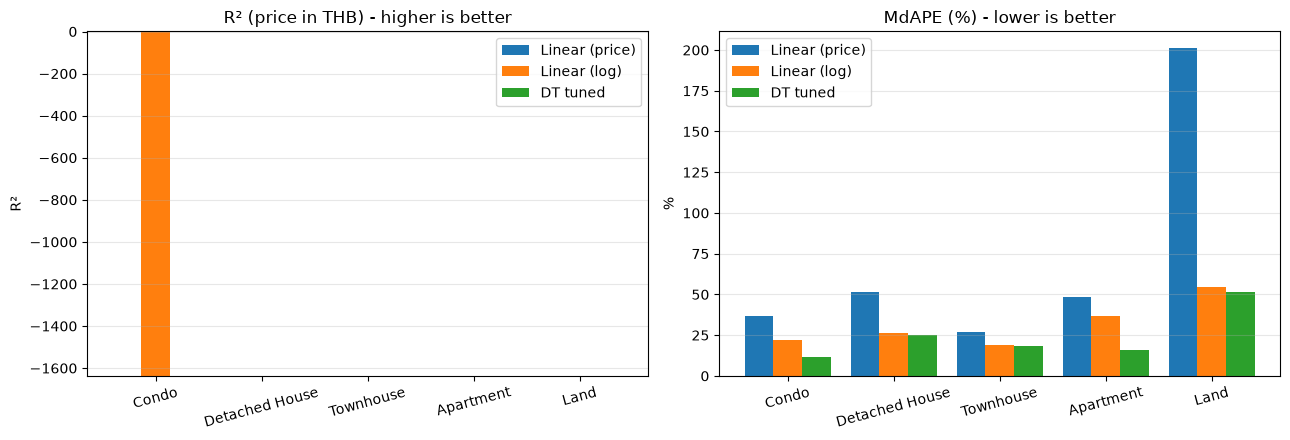

In [89]:
group_names = ['Condo', 'Detached House', 'Townhouse', 'Apartment', 'Land']
model_names = ['Linear (price)', 'Linear (log)', 'DT tuned']
positions = np.arange(len(group_names))
width = 0.27

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for k, model_name in enumerate(model_names):
    values = lin_vs_dt.xs(model_name, level='model').loc[group_names]
    axes[0].bar(positions + (k - 1) * width, values['R2'], width, label=model_name)
    axes[1].bar(positions + (k - 1) * width, values['MdAPE'], width, label=model_name)

axes[0].set_title('R² (price in THB) - higher is better')
axes[0].set_ylabel('R²')
axes[0].set_ylim(min(0, lin_vs_dt['R2'].min()), 1)
axes[1].set_title('MdAPE (%) - lower is better')
axes[1].set_ylabel('%')
for ax in axes:
    ax.set_xticks(positions)
    ax.set_xticklabels(group_names, rotation=15)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

#### 12.9.2 Actual vs Predicted: Linear (log) เทียบกับ Decision Tree

ถ้าโมเดลดี จุดจะเกาะเส้นประ ให้ดูว่าที่ราคาต่ำและราคาสูง Linear เบี้ยวออกจากเส้นอย่างเป็นระบบหรือไม่ (เส้นตรงจับความสัมพันธ์ที่โค้งไม่ได้)

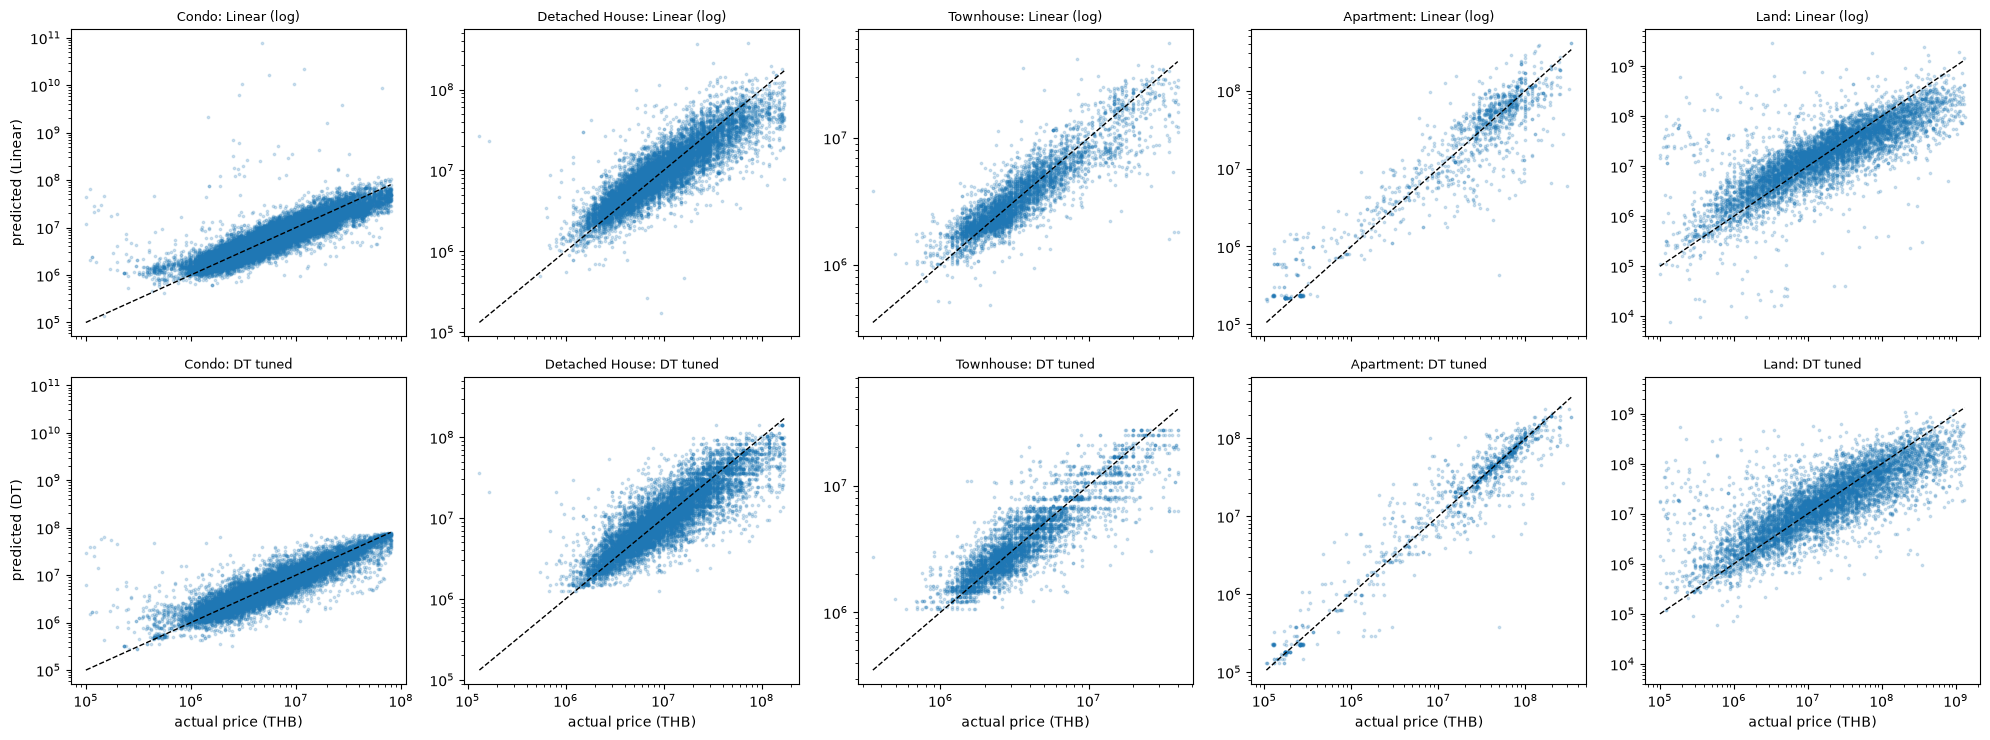

In [90]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7.5), sharex='col', sharey='col')

pairs = [
    ('Condo', price_test_condo, predict_price_linear(lin_log_condo, X_lin_test_condo, PER_AREA_CONDO),
     predict_price(model_condo, X_test_condo, PER_AREA_CONDO)),
    ('Detached House', price_test_house, predict_price_linear(lin_log_house, X_lin_test_house, PER_AREA_HOUSE),
     predict_price(model_house, X_test_house, PER_AREA_HOUSE)),
    ('Townhouse', price_test_townhouse, predict_price_linear(lin_log_townhouse, X_lin_test_townhouse, PER_AREA_TOWNHOUSE),
     predict_price(model_townhouse, X_test_townhouse, PER_AREA_TOWNHOUSE)),
    ('Apartment', price_test_apartment, predict_price_linear(lin_log_apartment, X_lin_test_apartment, PER_AREA_APARTMENT),
     predict_price(model_apartment, X_test_apartment, PER_AREA_APARTMENT)),
    ('Land', price_test_land, predict_price_linear(lin_log_land, X_lin_test_land, PER_AREA_LAND),
     predict_price(model_land, X_test_land, PER_AREA_LAND)),
]

for col, (name, actual, pred_lin, pred_dt) in enumerate(pairs):
    lo, hi = actual.min(), actual.max()
    for row, (pred, label) in enumerate([(pred_lin, 'Linear (log)'), (pred_dt, 'DT tuned')]):
        ax = axes[row, col]
        ax.scatter(actual, pred, s=3, alpha=0.2)
        ax.plot([lo, hi], [lo, hi], linestyle='--', color='black', linewidth=1)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'{name}: {label}', fontsize=9)
    axes[1, col].set_xlabel('actual price (THB)')
axes[0, 0].set_ylabel('predicted (Linear)')
axes[1, 0].set_ylabel('predicted (DT)')
plt.tight_layout()
plt.show()

#### 12.9.3 ทำไม Linear Regression ไม่เหมาะกับข้อมูลชุดนี้

ให้ตรวจตัวเลขในตาราง 12.9 ประกอบทุกข้อ

1. **ราคาไม่ได้โตเป็นเส้นตรงกับพื้นที่** ราคาต่อตารางเมตรของห้องใหญ่ ทำเลดี หรือโครงการหรู สูงกว่าห้องเล็กทั่วไปหลายเท่า เส้นตรงเส้นเดียวจึงทำนายราคาถูกเกินจริงที่ปลายแพง และแพงเกินจริงที่ปลายถูก (ดูการเบี้ยวออกจากเส้นประใน 12.9.2)
2. **ทำนายราคาติดลบได้** ดูคอลัมน์ `neg_pred_%` ของ `Linear (price)` สมการเส้นตรงไม่มีอะไรห้ามผลลัพธ์ต่ำกว่า 0 ซึ่งเป็นไปไม่ได้สำหรับราคา
3. **ผลของแต่ละ feature ถูกบังคับให้คงที่ทุกที่** เช่น ห้องน้ำเพิ่ม 1 ห้องต้องเพิ่มราคาเท่ากันทั้งคอนโดในวัฒนาและบ้านต่างจังหวัด ส่วน Decision Tree แบ่งข้อมูลเป็นกลุ่มย่อยก่อน แต่ละกลุ่มจึงมีความสัมพันธ์ของตัวเองได้ (interaction)
4. **ค่าว่างที่ V3 เติมเป็น `-1`** ต้นไม้ใช้ได้ทันที แต่ Linear ต้องเตรียมเพิ่ม (มัธยฐาน + flag) และยังเรียนรู้ได้แค่ "ค่าว่างทำให้ราคาเปลี่ยนเท่ากันทุกแถว"

**การแปลง log ช่วย Linear ได้บางส่วน** เพราะเปลี่ยนความสัมพันธ์แบบ "คูณ" ให้เป็น "บวก" ถ้า `Linear (log)` ได้ผลใกล้ Decision Tree ในบางกลุ่ม (มักเป็น Land ซึ่งเหลือแค่ทำเล) แปลว่ากลุ่มนั้นราคาขึ้นกับทำเลเป็นหลัก ซึ่งเป็นข้อสังเกตที่ควรเขียนในรายงานตามจริง ส่วนกลุ่มที่ Decision Tree ชนะชัด คือกลุ่มที่ feature มีผลร่วมกันแบบไม่เป็นเส้นตรง